<h1 style="text-align: center;">Project Title: AI Driven Risk Intelligence for 2026 Interpol Fugitives</h1>


### Course and Section: CS610 Applied Machine Learning (G1)

#### Team Members: 
Cathy CHU Shan-hui <br>
Dian Farah BINTE RIDUAN <br>
GOH See Ting <br>
KARANAM Akshit <br>
TAN Wenying Audrey 

<br>

## Create new environment

## Installed packages

## Import libraries and packages

In [1]:
import pandas as pd
import numpy as np

import json
import os
import requests
from io import StringIO  # Add this import
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx

from transformers import pipeline
import torch
import pandas as pd
from tqdm.auto import tqdm   # progress bar
import spacy

import ast
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              roc_auc_score, precision_score,
                              recall_score, f1_score, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               IsolationForest)
from sklearn.svm import SVC

## Import and clean data

### Import Json files: Physical traits

We want hair colour, height etc.

In [2]:
# 'lines=True' tells pandas to expect one JSON object per line
df_attributes = pd.read_json('targets.nested.json', lines=True)
df_attributes.head()

,id,caption,schema,referents,datasets,origin,first_seen,last_seen,last_change,properties,target
0,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,Person,[interpol-red-2019-108810],[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'birthPlace': ['KOFARNIKHON TOWN'], 'country'...",True
1,NK-22baaNEkbgBeZokNLmpaKd,DZHAMBULAT GALIMOV,Person,[interpol-red-2016-62557],[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'programId': ['INTERPOL-RN'], 'name': ['DZHAM...",True
2,NK-282timUs47w9otBkgPN6hw,KHAVA EFENDIEVA,Person,"[interpol-red-2021-16004, be-fod-4a0508d192593...",[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'name': ['KHAVA EFENDIEVA'], 'programId': ['I...",True
3,NK-2Ld7pewCoLeyspMtVCMMMo,JIAN XIA,Person,"[nl-wanted-jian-xia, interpol-red-2010-24537]",[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'nationality': ['cn'], 'lastName': ['XIA'], '...",True
4,NK-2SjjvqaYqkvk965QDYYMmA,NORBERT BIALAS,Person,[pl-wanted-8082399f5bf336744dcd0c313f9124a730b...,[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2025-08-04T18:27:01,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'gender': ['male'], 'lastName': ['BIALAS'], '...",True


In [3]:
def extract_from_props(prop_dict):
    # Initialize results
    res = {'height': np.nan, 'hairColor': np.nan, 'eyeColor': np.nan}
    
    # Ensure prop_dict is actually a dictionary
    if isinstance(prop_dict, dict):
        # 1. Extract Height
        h = prop_dict.get('height')
        if isinstance(h, list) and len(h) > 0:
            res['height'] = h[0]
            
        # 2. Extract Hair Color
        hc = prop_dict.get('hairColor')
        if isinstance(hc, list) and len(hc) > 0:
            res['hairColor'] = hc[0]
            
        # 3. Extract Place of Birth (birthPlace in your JSON)
        bp = prop_dict.get('eyeColor')
        if isinstance(bp, list) and len(bp) > 0:
            res['eyeColor'] = bp[0]
            
    return pd.Series(res)

# Apply to create the 3 columns
df_attributes[['height', 'hairColor', 'eyeColor']] = df_attributes['properties'].apply(extract_from_props)

df_attributes.head()

,id,caption,schema,referents,datasets,origin,first_seen,last_seen,last_change,properties,target,height,hairColor,eyeColor
0,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,Person,[interpol-red-2019-108810],[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'birthPlace': ['KOFARNIKHON TOWN'], 'country'...",True,NaN,OTHD,OTHD
1,NK-22baaNEkbgBeZokNLmpaKd,DZHAMBULAT GALIMOV,Person,[interpol-red-2016-62557],[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'programId': ['INTERPOL-RN'], 'name': ['DZHAM...",True,NaN,NaN,NaN
2,NK-282timUs47w9otBkgPN6hw,KHAVA EFENDIEVA,Person,"[interpol-red-2021-16004, be-fod-4a0508d192593...",[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'name': ['KHAVA EFENDIEVA'], 'programId': ['I...",True,1.75,BLA,BLA
3,NK-2Ld7pewCoLeyspMtVCMMMo,JIAN XIA,Person,"[nl-wanted-jian-xia, interpol-red-2010-24537]",[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2024-03-04T17:09:51,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'nationality': ['cn'], 'lastName': ['XIA'], '...",True,NaN,NaN,NaN
4,NK-2SjjvqaYqkvk965QDYYMmA,NORBERT BIALAS,Person,[pl-wanted-8082399f5bf336744dcd0c313f9124a730b...,[interpol_red_notices],[https://ws-public.interpol.int/notices/v1/red...,2025-08-04T18:27:01,2025-12-27T00:27:04,2025-10-06T18:27:01,"{'gender': ['male'], 'lastName': ['BIALAS'], '...",True,1.80,NaN,NaN


In [4]:
# Define the columns to keep
cols_to_keep = ['id', 'hairColor', 'height', 'eyeColor']

# Overwrite the existing df or create a new one
df_attributes = df_attributes[cols_to_keep]

# Display the result
df_attributes.head(200)

,id,hairColor,height,eyeColor
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD
1,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN
2,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA
3,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN
4,NK-2SjjvqaYqkvk965QDYYMmA,NaN,1.80,NaN
...,...,...,...,...
195,NK-Tni7zpYpppNmepcdaJduJg,NaN,NaN,NaN
196,NK-TrWQowvHXFeLJy7ZQmS9Tf,NaN,NaN,NaN
197,NK-TtFZdmaBd8oowwgaA9iB5j,OTHD,NaN,NaN
198,NK-TxHetytZM4Bf3b8WVqFamf,BLA,1.78,BLA


### Another Json: Background

In [5]:
# 'lines=True' tells pandas to expect one JSON object per line
df = pd.read_json('senzing.json', lines=True)
df.head()

,DATA_SOURCE,RECORD_ID,RECORD_TYPE,LAST_CHANGE,NAMES,GENDER,RISKS,DATES,ADDRESSES,COUNTRIES,IDENTIFIERS,URL
0,OS_INTERPOL_RED_NOTICES,NK-224TRezPqwzhQZ37exWxtX,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'SANAVB...",F,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1992-06-28'}],[{'PLACE_OF_BIRTH': 'KOFARNIKHON TOWN'}],"[{'NATIONALITY': 'tj'}, {'NATIONALITY': 'ru'}]","[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-224T...
1,OS_INTERPOL_RED_NOTICES,NK-22baaNEkbgBeZokNLmpaKd,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'DZHAMB...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1989-01-05'}],[{'PLACE_OF_BIRTH': 'DAGESTAN REPUBLIC'}],[{'NATIONALITY': 'ru'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-22ba...
2,OS_INTERPOL_RED_NOTICES,NK-282timUs47w9otBkgPN6hw,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'KHAVA ...",F,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1982-05-24'}],"[{'PLACE_OF_BIRTH': 'GROZNY, CHECHEN REPUBLIC'}]",[{'NATIONALITY': 'ru'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-282t...
3,OS_INTERPOL_RED_NOTICES,NK-2Ld7pewCoLeyspMtVCMMMo,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'JIAN X...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1977-07-13'}],[{'PLACE_OF_BIRTH': 'LIAONING'}],[{'NATIONALITY': 'cn'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-2Ld7...
4,OS_INTERPOL_RED_NOTICES,NK-2SjjvqaYqkvk965QDYYMmA,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'NORBER...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1978-12-28'}],NaN,[{'NATIONALITY': 'pl'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-2Sjj...


We want the 'RECORD_ID', 'GENDER', 'Address', 'primary_name'

In [6]:
# To get the FIRST name (Index 0)
df['Address'] = df['ADDRESSES'].apply(lambda x: x[0].get('PLACE_OF_BIRTH') if isinstance(x, list) and len(x) > 0 else None)

# View the results
df[['ADDRESSES', 'Address']].head()

df.head()

,DATA_SOURCE,RECORD_ID,RECORD_TYPE,LAST_CHANGE,NAMES,GENDER,RISKS,DATES,ADDRESSES,COUNTRIES,IDENTIFIERS,URL,Address
0,OS_INTERPOL_RED_NOTICES,NK-224TRezPqwzhQZ37exWxtX,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'SANAVB...",F,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1992-06-28'}],[{'PLACE_OF_BIRTH': 'KOFARNIKHON TOWN'}],"[{'NATIONALITY': 'tj'}, {'NATIONALITY': 'ru'}]","[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-224T...,KOFARNIKHON TOWN
1,OS_INTERPOL_RED_NOTICES,NK-22baaNEkbgBeZokNLmpaKd,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'DZHAMB...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1989-01-05'}],[{'PLACE_OF_BIRTH': 'DAGESTAN REPUBLIC'}],[{'NATIONALITY': 'ru'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-22ba...,DAGESTAN REPUBLIC
2,OS_INTERPOL_RED_NOTICES,NK-282timUs47w9otBkgPN6hw,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'KHAVA ...",F,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1982-05-24'}],"[{'PLACE_OF_BIRTH': 'GROZNY, CHECHEN REPUBLIC'}]",[{'NATIONALITY': 'ru'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-282t...,"GROZNY, CHECHEN REPUBLIC"
3,OS_INTERPOL_RED_NOTICES,NK-2Ld7pewCoLeyspMtVCMMMo,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'JIAN X...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1977-07-13'}],[{'PLACE_OF_BIRTH': 'LIAONING'}],[{'NATIONALITY': 'cn'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-2Ld7...,LIAONING
4,OS_INTERPOL_RED_NOTICES,NK-2SjjvqaYqkvk965QDYYMmA,PERSON,2025-10-06T18:27:01,"[{'NAME_TYPE': 'PRIMARY', 'NAME_FULL': 'NORBER...",M,"[{'TOPIC': 'crime'}, {'TOPIC': 'wanted'}]",[{'DATE_OF_BIRTH': '1978-12-28'}],NaN,[{'NATIONALITY': 'pl'}],"[{'OTHER_ID_TYPE': 'OPEN_SANCTIONS', 'OTHER_ID...",https://www.opensanctions.org/entities/NK-2Sjj...,None


In [7]:
target_columns = ['DATA_SOURCE', 'RECORD_ID', 'RECORD_TYPE', 'RISKS', 'ADDRESSES', 'COUNTRIES', 'IDENTIFIERS']
unique_results = {}

for col in target_columns:
    if col in df.columns:
        # 1. Explode lists into individual rows
        exploded = df[col].explode().dropna()
        
        # 2. Convert any dictionaries to JSON strings so they are hashable
        # This turns {'a': 1} into '{"a": 1}'
        processed = exploded.apply(lambda x: json.dumps(x, sort_keys=True) if isinstance(x, dict) else x)
        
        # 3. Now we can safely get unique values
        uniques = processed.unique().tolist()
        unique_results[col] = uniques
        
        print(f"--- {col}: {len(uniques)} unique items ---")
        print(uniques[:5]) # Show sample
    else:
        print(f" Column {col} not found.")

--- DATA_SOURCE: 1 unique items ---
['OS_INTERPOL_RED_NOTICES']
--- RECORD_ID: 6479 unique items ---
['NK-224TRezPqwzhQZ37exWxtX', 'NK-22baaNEkbgBeZokNLmpaKd', 'NK-282timUs47w9otBkgPN6hw', 'NK-2Ld7pewCoLeyspMtVCMMMo', 'NK-2SjjvqaYqkvk965QDYYMmA']
--- RECORD_TYPE: 1 unique items ---
['PERSON']
--- RISKS: 2 unique items ---
['{"TOPIC": "crime"}', '{"TOPIC": "wanted"}']
--- ADDRESSES: 3855 unique items ---
['{"PLACE_OF_BIRTH": "KOFARNIKHON TOWN"}', '{"PLACE_OF_BIRTH": "DAGESTAN REPUBLIC"}', '{"PLACE_OF_BIRTH": "GROZNY, CHECHEN REPUBLIC"}', '{"PLACE_OF_BIRTH": "LIAONING"}', '{"PLACE_OF_BIRTH": "TRIPOLI"}']
--- COUNTRIES: 142 unique items ---
['{"NATIONALITY": "tj"}', '{"NATIONALITY": "ru"}', '{"NATIONALITY": "cn"}', '{"NATIONALITY": "pl"}', '{"NATIONALITY": "ly"}']
--- IDENTIFIERS: 6479 unique items ---
['{"OTHER_ID_NUMBER": "NK-224TRezPqwzhQZ37exWxtX", "OTHER_ID_TYPE": "OPEN_SANCTIONS"}', '{"OTHER_ID_NUMBER": "NK-22baaNEkbgBeZokNLmpaKd", "OTHER_ID_TYPE": "OPEN_SANCTIONS"}', '{"OTHER_ID_NU

In [8]:
# Define the columns to keep
cols_to_keep = ['RECORD_ID', 'GENDER', 'Address']

# Overwrite the existing df or create a new one
df = df[cols_to_keep]

# Rename 'record' to 'id'
df = df.rename(columns={'RECORD_ID': 'id'})

# Display the result
df.head()

,id,GENDER,Address
0,NK-224TRezPqwzhQZ37exWxtX,F,KOFARNIKHON TOWN
1,NK-22baaNEkbgBeZokNLmpaKd,M,DAGESTAN REPUBLIC
2,NK-282timUs47w9otBkgPN6hw,F,"GROZNY, CHECHEN REPUBLIC"
3,NK-2Ld7pewCoLeyspMtVCMMMo,M,LIAONING
4,NK-2SjjvqaYqkvk965QDYYMmA,M,None


### Webscrape: Country label

We want the label of the country

In [9]:
url = 'https://followthemoney.tech/explorer/types/country/'

# Fetch the page
header = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=header)

# Wrap response.text in StringIO()
# This treats the string like a file-like object, which Pandas now prefers
tables = pd.read_html(StringIO(response.text))

# The list of territories is the second table (index 1)
df_ftm = tables[1]

# Display the result
print(df_ftm.head())

    Code                 Label FtM  Country  Jurisdiction  Historical Wikidata
0     ac      Ascension Island  ac      NaN           NaN         NaN   Q46197
1     ad               Andorra  ad      NaN           NaN         NaN     Q228
2     ae  United Arab Emirates  ae      NaN           NaN         NaN     Q878
3  ae-aj                ‘Ajmān  ae      NaN           NaN         NaN  Q159477
4  ae-az             Abu Dhabi  ae      NaN           NaN         NaN  Q187712


### Import csv files

In [10]:
# Load the dataset
df_csv = pd.read_csv('targets.simple.csv')

# View the first few rows
print(df_csv.head())

                          id  schema                 name aliases  birth_date  \
0  NK-224TRezPqwzhQZ37exWxtX  Person  SANAVBARI NIKITENKO     NaN  1992-06-28   
1  NK-22baaNEkbgBeZokNLmpaKd  Person   DZHAMBULAT GALIMOV     NaN  1989-01-05   
2  NK-282timUs47w9otBkgPN6hw  Person      KHAVA EFENDIEVA     NaN  1982-05-24   
3  NK-2Ld7pewCoLeyspMtVCMMMo  Person             JIAN XIA     NaN  1977-07-13   
4  NK-2SjjvqaYqkvk965QDYYMmA  Person       NORBERT BIALAS     NaN  1978-12-28   

  countries  addresses  identifiers  \
0     ru;tj        NaN          NaN   
1        ru        NaN          NaN   
2        ru        NaN          NaN   
3        cn        NaN          NaN   
4        pl        NaN          NaN   

                                           sanctions  phones  emails  \
0  "participation in the activity of a terrorist ...     NaN     NaN   
1           Participation in illegal armed formation     NaN     NaN   
2           Participation in illegal armed formation     NaN  

In [11]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6469 entries, 0 to 6468
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           6469 non-null   object 
 1   schema       6469 non-null   object 
 2   name         6469 non-null   object 
 3   aliases      2 non-null      object 
 4   birth_date   6465 non-null   object 
 5   countries    6424 non-null   object 
 6   addresses    0 non-null      float64
 7   identifiers  0 non-null      float64
 8   sanctions    6467 non-null   object 
 9   phones       0 non-null      float64
 10  emails       0 non-null      float64
 11  program_ids  6467 non-null   object 
 12  dataset      6469 non-null   object 
 13  first_seen   6469 non-null   object 
 14  last_seen    6469 non-null   object 
 15  last_change  6469 non-null   object 
dtypes: float64(4), object(12)
memory usage: 808.8+ KB


### Data cleaning and merging csv with webscraped data

In [12]:
# 1. Convert Date columns
date_cols = ['birth_date', 'first_seen', 'last_seen', 'last_change']
for col in date_cols:
    df_csv[col] = pd.to_datetime(df_csv[col], errors='coerce')

# 2. Convert Categorical columns for memory efficiency
cat_cols = ['schema', 'dataset', 'countries']
for col in cat_cols:
    df_csv[col] = df_csv[col].astype('category')

# 3. Handle the empty float columns
# Converting them to object/string prevents math errors later
empty_cols = ['addresses', 'identifiers', 'phones', 'emails']
for col in empty_cols:
    df_csv[col] = df_csv[col].astype('object')

# 4. Verify the changes
print(df_csv.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6469 entries, 0 to 6468
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           6469 non-null   object        
 1   schema       6469 non-null   category      
 2   name         6469 non-null   object        
 3   aliases      2 non-null      object        
 4   birth_date   6347 non-null   datetime64[ns]
 5   countries    6424 non-null   category      
 6   addresses    0 non-null      object        
 7   identifiers  0 non-null      object        
 8   sanctions    6467 non-null   object        
 9   phones       0 non-null      object        
 10  emails       0 non-null      object        
 11  program_ids  6467 non-null   object        
 12  dataset      6469 non-null   category      
 13  first_seen   6469 non-null   datetime64[ns]
 14  last_seen    6469 non-null   datetime64[ns]
 15  last_change  6469 non-null   datetime64[ns]
dtypes: cat

In [13]:
# Create a temporary dataframe with one country per row
df_exploded = df_csv.assign(countries=df_csv['countries'].str.split(';')).explode('countries')

# merge normally
df_exploded = df_exploded.merge(df_ftm[['Code', 'Label']], left_on='countries', right_on='Code', how='left')

In [14]:
df_exploded.head()

,id,schema,name,aliases,birth_date,countries,addresses,identifiers,sanctions,phones,emails,program_ids,dataset,first_seen,last_seen,last_change,Code,Label
0,NK-224TRezPqwzhQZ37exWxtX,Person,SANAVBARI NIKITENKO,NaN,1992-06-28,ru,NaN,NaN,"""participation in the activity of a terrorist ...",NaN,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia
1,NK-224TRezPqwzhQZ37exWxtX,Person,SANAVBARI NIKITENKO,NaN,1992-06-28,tj,NaN,NaN,"""participation in the activity of a terrorist ...",NaN,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,tj,Tajikistan
2,NK-22baaNEkbgBeZokNLmpaKd,Person,DZHAMBULAT GALIMOV,NaN,1989-01-05,ru,NaN,NaN,Participation in illegal armed formation,NaN,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia
3,NK-282timUs47w9otBkgPN6hw,Person,KHAVA EFENDIEVA,NaN,1982-05-24,ru,NaN,NaN,Participation in illegal armed formation,NaN,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia
4,NK-2Ld7pewCoLeyspMtVCMMMo,Person,JIAN XIA,NaN,1977-07-13,cn,NaN,NaN,"""1) Murder\n2) Manslaughter\n3) Aggravated theft""",NaN,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,cn,China


### Merging with Json files

In [15]:
# merge
df_final = pd.merge(df_exploded, df, on='id', how='left')
# merge
df_final = pd.merge(df_attributes, df_final, on='id', how='left')
df_final.head()

,id,hairColor,height,eyeColor,schema,name,aliases,birth_date,countries,addresses,...,emails,program_ids,dataset,first_seen,last_seen,last_change,Code,Label,GENDER,Address
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,Person,SANAVBARI NIKITENKO,NaN,1992-06-28,ru,NaN,...,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,KOFARNIKHON TOWN
1,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,Person,SANAVBARI NIKITENKO,NaN,1992-06-28,tj,NaN,...,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,tj,Tajikistan,F,KOFARNIKHON TOWN
2,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN,Person,DZHAMBULAT GALIMOV,NaN,1989-01-05,ru,NaN,...,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,M,DAGESTAN REPUBLIC
3,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA,Person,KHAVA EFENDIEVA,NaN,1982-05-24,ru,NaN,...,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,"GROZNY, CHECHEN REPUBLIC"
4,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN,Person,JIAN XIA,NaN,1977-07-13,cn,NaN,...,NaN,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,cn,China,M,LIAONING


In [16]:
# 1. Define the list of columns to remove
cols_to_drop = ['schema', 'aliases', 'countries', 'addresses', 'identifiers', 'dataset', 'phones', 'emails']

# 2. Drop them and create a new DataFrame
df_cleaned = df_final.drop(columns=cols_to_drop)

df_cleaned.tail()

,id,hairColor,height,eyeColor,name,birth_date,sanctions,program_ids,first_seen,last_seen,last_change,Code,Label,GENDER,Address
7052,interpol-red-2025-97437,NaN,1.85,NaN,JOHAN MARCO ROSSI,1983-07-20,1-2. Gross accounting offence 3. Gross money l...,INTERPOL-RN,2025-12-16 18:56:05,2026-01-14 09:27:01,2025-12-24 18:27:02,se,Sweden,M,Malmö
7053,interpol-red-2025-98243,NaN,NaN,NaN,AMADEU DA COSTA FILHO,1965-09-25,Organización Criminal,INTERPOL-RN,2025-12-18 19:03:58,2026-01-14 09:27:01,2025-12-18 19:03:58,br,Brazil,M,Jardim Alegre/PR
7054,interpol-red-2025-98916,NaN,NaN,NaN,MAGDALENA STANISLAWA SZAFRAN GORCZYCA,1986-07-10,"unlawful deprivation of liberty, accompanied b...",INTERPOL-RN,2025-12-23 00:28:48,2026-01-14 09:27:01,2026-01-09 01:06:39,pl,Poland,F,Krosno
7055,interpol-red-2025-99289,OTHD,1.91,OTHL,PIOTR PAWEL ADAMCZEWSKI,1992-05-20,"assault resulting in death, grievous bodily in...",INTERPOL-RN,2025-12-18 01:10:02,2026-01-14 09:27:01,2025-12-25 09:27:01,pl,Poland,M,KALISZ
7056,interpol-red-2025-99577,NaN,1.70,NaN,ANDREI CASTELLI,1985-08-25,Double Aggravated Homicide and Tampering with ...,INTERPOL-RN,2025-12-26 18:27:01,2026-01-14 09:27:01,2025-12-26 18:27:01,br,Brazil,M,Salto do Lontra/PR


In [17]:
df_cleaned.shape

(7057, 15)

In [18]:
df_cleaned.describe()

,birth_date,first_seen,last_seen,last_change
count,6910,7041,7041,7041
mean,1982-04-10 14:45:40.376266240,2024-03-30 12:56:12.059792384,2026-01-14 09:27:00.999999744,2025-09-28 16:33:21.220565248
min,1925-10-02 00:00:00,2024-03-03 18:27:01,2026-01-14 09:27:01,2025-09-15 18:27:02
25%,1975-08-17 06:00:00,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-09-15 18:27:02
50%,1985-04-20 00:00:00,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01
75%,1991-02-11 06:00:00,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01
max,2006-05-30 00:00:00,2025-12-29 09:27:01,2026-01-14 09:27:01,2026-01-09 01:06:39


In [19]:
# Calculate age in years
# Note: we divide by a Timedelta of 1 year (365.25 days) to get a float
df_cleaned['age_at_first_seen'] = (df_cleaned['first_seen'] - df_cleaned['birth_date']) / pd.Timedelta(days=365.25)

# Round to 1 decimal place for readability
df_cleaned['age_at_first_seen'] = df_cleaned['age_at_first_seen'].round(1)

In [20]:
current_date = datetime.now()
df_cleaned['days_at_large'] = (df_cleaned['last_seen'] - df_cleaned['first_seen']).dt.days

In [21]:
# Calculates total days and divides by the average length of a year
df_cleaned['age_today'] = (current_date - df_cleaned['birth_date']).dt.days // 365.25

In [22]:
# Calculate the difference in years
df_cleaned['age_at_last_seen'] = (df_cleaned['last_seen'] - df_cleaned['birth_date'])/ pd.Timedelta(days=365.25)

# Adjust for whether the birthday had occurred yet in that specific year
# We check if (month, day) of 'last seen' is before (month, day) of 'birthday'
has_not_had_birthday = (
    (df_cleaned['last_seen'].dt.month < df_cleaned['birth_date'].dt.month) | 
    ((df_cleaned['last_seen'].dt.month == df_cleaned['birth_date'].dt.month) & 
     (df_cleaned['last_seen'].dt.day < df_cleaned['birth_date'].dt.day))
)

df_cleaned.loc[has_not_had_birthday, 'age_at_last_seen'] -= 1

# round
df_cleaned['age_at_last_seen'] = df_cleaned['age_at_last_seen'].round(1)

df_cleaned.head()

,id,hairColor,height,eyeColor,name,birth_date,sanctions,program_ids,first_seen,last_seen,last_change,Code,Label,GENDER,Address,age_at_first_seen,days_since_last_change,age_today,age_at_last_seen
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5
1,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,tj,Tajikistan,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5
2,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN,DZHAMBULAT GALIMOV,1989-01-05,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,M,DAGESTAN REPUBLIC,35.2,114.0,37.0,37.0
3,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA,KHAVA EFENDIEVA,1982-05-24,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,"GROZNY, CHECHEN REPUBLIC",41.8,114.0,43.0,42.6
4,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN,JIAN XIA,1977-07-13,"""1) Murder\n2) Manslaughter\n3) Aggravated theft""",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,cn,China,M,LIAONING,46.6,114.0,48.0,47.5


In [23]:
# Find records where birth date is logically impossible (after they were seen)
errors = df_cleaned[df_cleaned['age_at_first_seen'] < 0]
print(f"Number of date logic errors: {len(errors)}")

Number of date logic errors: 0


In [24]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7057 entries, 0 to 7056
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      7057 non-null   object        
 1   hairColor               3298 non-null   object        
 2   height                  3200 non-null   object        
 3   eyeColor                2940 non-null   object        
 4   name                    7041 non-null   object        
 5   birth_date              6910 non-null   datetime64[ns]
 6   sanctions               7041 non-null   object        
 7   program_ids             7041 non-null   object        
 8   first_seen              7041 non-null   datetime64[ns]
 9   last_seen               7041 non-null   datetime64[ns]
 10  last_change             7041 non-null   datetime64[ns]
 11  Code                    6996 non-null   object        
 12  Label                   6996 non-null   object  

In [25]:
df_cleaned.head()

,id,hairColor,height,eyeColor,name,birth_date,sanctions,program_ids,first_seen,last_seen,last_change,Code,Label,GENDER,Address,age_at_first_seen,days_since_last_change,age_today,age_at_last_seen
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5
1,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,tj,Tajikistan,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5
2,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN,DZHAMBULAT GALIMOV,1989-01-05,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,M,DAGESTAN REPUBLIC,35.2,114.0,37.0,37.0
3,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA,KHAVA EFENDIEVA,1982-05-24,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,ru,Russia,F,"GROZNY, CHECHEN REPUBLIC",41.8,114.0,43.0,42.6
4,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN,JIAN XIA,1977-07-13,"""1) Murder\n2) Manslaughter\n3) Aggravated theft""",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,2025-10-06 18:27:01,cn,China,M,LIAONING,46.6,114.0,48.0,47.5


### Cleaned to lowercase

In [26]:
df_cleaned['sanctions_clean'] = df_cleaned['sanctions'].str.lower()

df_cleaned['address'] = df_cleaned['Address'].str.lower()

df_cleaned['label'] = df_cleaned['Label'].str.lower()

## ======LDA REVISION STARTS HERE======

### Saving and loading

In [71]:
# Save the final cleaned dataframe to a csv
df_cleaned.to_csv('crime_analysis_results.csv', index=False)
print("File saved successfully as 'crime_analysis_results.csv'")

File saved successfully as 'crime_analysis_results.csv'


In [72]:
# Load the data back
df_cleaned = pd.read_csv('data/crime_analysis_results.csv')
df_cleaned.head()

,id,hairColor,height,eyeColor,name,birth_date,sanctions,program_ids,first_seen,last_seen,...,Label,GENDER,Address,age_at_first_seen,days_since_last_change,age_today,age_at_last_seen,sanctions_clean,address,label
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5,"""participation in the activity of a terrorist ...",kofarnikhon town,russia
1,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Tajikistan,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5,"""participation in the activity of a terrorist ...",kofarnikhon town,tajikistan
2,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN,DZHAMBULAT GALIMOV,1989-01-05,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,M,DAGESTAN REPUBLIC,35.2,114.0,37.0,37.0,participation in illegal armed formation,dagestan republic,russia
3,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA,KHAVA EFENDIEVA,1982-05-24,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,F,"GROZNY, CHECHEN REPUBLIC",41.8,114.0,43.0,42.6,participation in illegal armed formation,"grozny, chechen republic",russia
4,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN,JIAN XIA,1977-07-13,"""1) Murder\n2) Manslaughter\n3) Aggravated theft""",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,China,M,LIAONING,46.6,114.0,48.0,47.5,"""1) murder\n2) manslaughter\n3) aggravated theft""",liaoning,china


In [73]:
df_cleaned.dtypes

id                            str
hairColor                     str
height                    float64
eyeColor                      str
name                          str
birth_date                    str
sanctions                     str
program_ids                   str
first_seen                    str
last_seen                     str
last_change                   str
Code                          str
Label                         str
GENDER                        str
Address                       str
age_at_first_seen         float64
days_since_last_change    float64
age_today                 float64
age_at_last_seen          float64
sanctions_clean               str
address                       str
label                         str
dtype: object

In [74]:
df_cleaned['first_seen'].drop_duplicates().sort_values()

4942    2024-03-03 18:27:01
1086    2024-03-04 00:27:01
178     2024-03-04 09:27:18
0       2024-03-04 17:09:51
3896    2024-03-05 12:13:17
               ...         
7054    2025-12-23 00:28:48
7050    2025-12-24 09:27:01
7027    2025-12-26 18:27:01
3820    2025-12-29 09:27:01
913                     NaN
Name: first_seen, Length: 346, dtype: str

Check first_seen to extract news from 2024 to 2026

In [75]:
# drop duplicate cols.
columns_to_drop = ['Address','sanctions', 'Label']
df_cleaned = df_cleaned.drop(columns_to_drop, axis=1)

## Perform TRANSLATION

Checking English rows before NER.

In [76]:
print(df_cleaned.shape)
print(df_cleaned.columns.tolist())
df_cleaned['sanctions_clean'].head(10)

(7057, 19)
['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label']


0    "participation in the activity of a terrorist ...
1    "participation in the activity of a terrorist ...
2             participation in illegal armed formation
3             participation in illegal armed formation
4    "1) murder\n2) manslaughter\n3) aggravated theft"
5    assaulting a public officer, impeding official...
6    murder/accomplice, manslaughter accomplice,  k...
7    murder/accomplice, manslaughter accomplice,  k...
8    participation in an illegal armed formation - ...
9             participation in illegal armed formation
Name: sanctions_clean, dtype: str

Checking non-English rows

In [77]:
from langdetect import detect

def detect_language(text):
    try:
        if not isinstance(text, str) or len(text.strip()) < 5:
            return 'unknown'
        return detect(text)
    except:
        return 'unknown'

df_cleaned['detected_lang'] = df_cleaned['sanctions_clean'].apply(detect_language)
print(df_cleaned['detected_lang'].value_counts())

detected_lang
en         4329
es         1257
it          395
de          338
pt          178
fr          175
da          105
ca           50
unknown      45
fi           32
no           31
tl           13
so           13
pl           13
cy           12
af           12
et           11
ro           11
nl           10
hu            9
sq            5
sk            4
sv            2
hr            2
id            2
ar            1
sl            1
lt            1
Name: count, dtype: int64


4,363 English (62%) — majority but not overwhelming

2,694 non-English (38%) — significant portion that needs translation

Spanish (1,257) and Italian (356) are the biggest non-English groups

13+ languages total — quite diverse

Translation of non-EN text might be necessary.

What we will do next:

translate non-English rows → run TRANSFORMER > NER → LDA

In [78]:
!pip install deep-translator langdetect

In [79]:
from deep_translator import GoogleTranslator

def translate_if_needed(row):
    if row['detected_lang'] == 'en' or row['detected_lang'] == 'unknown':
        return row['sanctions_clean']
    try:
        text = str(row['sanctions_clean']).strip()
        if len(text) < 5:
            return text
        return GoogleTranslator(source='auto', target='en').translate(text)
    except Exception as e:
        return row['sanctions_clean']


results = []
for i, row in df_cleaned.iterrows():
    results.append(translate_if_needed(row))

df_cleaned['sanctions_translated'] = results

# Sanity check
non_eng = df_cleaned[df_cleaned['detected_lang'] != 'en'].head(10)
for i, row in non_eng.iterrows():
    print(f"\nOriginal  ({row['detected_lang']}): {row['sanctions_clean'][:100]}")
    print(f"Translated: {row['sanctions_translated'][:100]}")


Original  (cy): fraud
Translated: fraud

Original  (es): trafico ilicito de estupefacientes y drogas peligrosas, asociacion criminal y lavado de dinero.
Translated: illicit trafficking of narcotics and dangerous drugs, criminal association and money laundering.

Original  (es): "extorsion
sustancias psicotropicas 
organizacion o grupo delictivo
secuestro"
Translated: "extortion
psychotropic substances 
criminal organization or group
kidnapping"

Original  (tl): kidnaping
Translated: kidnapping

Original  (de): murder
Translated: murder

Original  (it): participation in illegal armed formation
Translated: participation in illegal armed formation

Original  (it): participation in illegal armed formation
Translated: participation in illegal armed formation

Original  (es): organizaciones terroristas, en calidad de cabecilla.
Translated: terrorist organizations, as their leader.

Original  (da): first degree murder
Translated: first degree murder

Original  (it): participation in a crimin

## Perform Transformer

BERT is better than Spacy for complex context and has high accuracy.

We have little to no labeled data, and categories are dynamic so we used zero-shot (LLM based) instead of legal bert (fined-tuned)

## Transformer: multi-label

═══════════════════════════════════════════════════════════════════
BART ZERO-SHOT CLASSIFICATION — MULTI-LABEL VERSION
═══════════════════════════════════════════════════════════════════

The original code saved only the top crime label per sanctions entry (e.g. "terrorism" with confidence 0.87). This means if an entry involved both terrorism and weapons, only terrorism was recorded.

For a compliance risk screening system, this is dangerous — missing a co-occurring crime type (e.g. weapons, trafficking) could mean a high-risk individual is under-flagged.
The updated code saves scores for ALL 7 crime labels per entry, keeping any label that scores >= 0.3 (30% confidence threshold).

This gives us a richer, multi-label view of each sanctions entry, which is more appropriate for compliance screening.

Example of improvement:

Before: detected_crime_type = "terrorism" (only)

After:  score_terrorism=0.87, score_weapons=0.45 (both flagged)


In [80]:
# ── 1. Device detection ───────────────────────────────────────────
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU ✅' if device == 0 else 'CPU (no GPU found)'}")

# ── 2. Load model ─────────────────────────────────────────────────
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
)

crime_labels = [
    "terrorism",
    "homicide",
    "financial crime",
    "cyber crime",
    "narcotics",
    "assault",
    "weapons"
]

# ── 3. Deduplicate texts before classifying ───────────────────────
texts_series = df_cleaned['sanctions_translated'].fillna("").astype(str).str.strip()

unique_texts  = texts_series.unique().tolist()
valid_texts   = [t for t in unique_texts if len(t) >= 5]
invalid_texts = [t for t in unique_texts if len(t) < 5]

print(f"Total rows      : {len(df_cleaned):,}")
print(f"Unique texts    : {len(unique_texts):,}  ← only classifying these")
print(f"Skipping (empty): {len(invalid_texts):,}")

# ── 4. Batch classify — save ALL label scores ─────────────────────
# CHANGE: results_map now stores a dict of {label: score} per text
# instead of just (top_label, top_score)
BATCH_SIZE = 16
results_map = {}

for i in range(0, len(valid_texts), BATCH_SIZE):
    batch = valid_texts[i : i + BATCH_SIZE]
    try:
        outputs = classifier(
            batch,
            candidate_labels=crime_labels,
            multi_label=True,
            batch_size=BATCH_SIZE,
        )
        for text, result in zip(batch, outputs):
            # CHANGE: save all labels scoring >= 0.3
            results_map[text] = {
                label: round(score, 4)
                for label, score in zip(result['labels'], result['scores'])
                if score >= 0.3
            }
    except Exception as e:
        print(f"⚠️  Batch {i//BATCH_SIZE} failed ({e}), falling back to single...")
        for text in batch:
            try:
                result = classifier(text, candidate_labels=crime_labels, multi_label=True)
                results_map[text] = {
                    label: round(score, 4)
                    for label, score in zip(result['labels'], result['scores'])
                    if score >= 0.3
                }
            except:
                results_map[text] = {}

# Empty/invalid texts get empty dict
for text in invalid_texts:
    results_map[text] = {}

# ── 5. Map results back to dataframe ──────────────────────────────
# CHANGE: create one score column per crime type
# e.g. score_terrorism, score_homicide, score_financial_crime etc.
for label in crime_labels:
    col_name = f'score_{label.replace(" ", "_")}'
    df_cleaned[col_name] = texts_series.map(
        lambda x, l=label: results_map.get(x, {}).get(l, 0.0)
    )

# Primary label = highest scoring crime type
df_cleaned['detected_crime_type'] = texts_series.map(
    lambda x: max(
        results_map.get(x, {'Unknown': 0.0}),
        key=results_map.get(x, {'Unknown': 0.0}).get
    ) if results_map.get(x) else 'Unknown'
)

# Primary confidence = score of the top label
df_cleaned['confidence_scores'] = texts_series.map(
    lambda x: max(results_map.get(x, {'Unknown': 0.0}).values())
    if results_map.get(x) else 0.0
)

# ── 6. Sanity check ───────────────────────────────────────────────
print(f"\nPrimary crime type distribution:")
print(df_cleaned['detected_crime_type'].value_counts())

print(f"\nLow confidence (<0.5): {(df_cleaned['confidence_scores'] < 0.5).sum():,} rows")

# Show multi-label example — entries flagged for 2+ crime types
score_cols = [f'score_{l.replace(" ", "_")}' for l in crime_labels]
df_cleaned['num_crime_types'] = (df_cleaned[score_cols] >= 0.3).sum(axis=1)
print(f"\nEntries flagged for multiple crime types:")
print(df_cleaned['num_crime_types'].value_counts().sort_index())

Device: CPU (no GPU found)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Total rows      : 7,057
Unique texts    : 2,939  ← only classifying these
Skipping (empty): 6

Primary crime type distribution:
detected_crime_type
terrorism          1863
weapons            1708
homicide           1429
assault             636
Unknown             477
narcotics           467
financial crime     457
cyber crime          20
Name: count, dtype: int64

Low confidence (<0.5): 682 rows

Entries flagged for multiple crime types:
num_crime_types
0     477
1    3071
2    2676
3     787
4      36
5       1
6       8
7       1
Name: count, dtype: int64


50% of entries involve 2 or more crime types. If keeping single-label only, half dataset would have been under-flagged for compliance screening.

## Saving BART result


In [81]:
df_cleaned.to_csv('data/crime_analysis_results_bart_ner.csv', index=False)
print("✅ Saved!")
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

✅ Saved!
Shape: (7057, 31)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types']


======= Below is the original transformer========

## Transformer: single label (don't run)

In [49]:
# ── 1. Device detection ───────────────────────────────────────────────────────
# Uses GPU if available (10-20x faster), otherwise CPU
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU ✅' if device == 0 else 'CPU (no GPU found)'}")

# ── 2. Load model ─────────────────────────────────────────────────────────────
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
)

crime_labels = [
    "terrorism",
    "homicide",
    "financial crime",
    "cyber crime",
    "narcotics",
    "assault",
    "weapons"
]

# ── 3. Clean and deduplicate texts before classifying ─────────────────────────
# Key insight: many sanctions texts are identical or near-identical
# No need to classify the same text 50 times
texts_series = df_cleaned['sanctions_translated'].fillna("").astype(str).str.strip()

unique_texts  = texts_series.unique().tolist()
valid_texts   = [t for t in unique_texts if len(t) >= 5]
invalid_texts = [t for t in unique_texts if len(t) < 5]

print(f"Total rows      : {len(df_cleaned):,}")
print(f"Unique texts    : {len(unique_texts):,}  ← only classifying these")
print(f"Skipping (empty): {len(invalid_texts):,}")

# ── 4. Batch classify unique texts only ───────────────────────────────────────
BATCH_SIZE = 16   # increase to 32 if you have GPU, lower to 8 if you get memory errors

results_map = {}   # text → (crime_type, confidence)

for i in tqdm(range(0, len(valid_texts), BATCH_SIZE), desc="Classifying"):
    batch = valid_texts[i : i + BATCH_SIZE]
    
    try:
        outputs = classifier(
            batch,
            candidate_labels=crime_labels,
            multi_label=True,
            batch_size=BATCH_SIZE,
        )
        # outputs is a list of result dicts when input is a list
        for text, result in zip(batch, outputs):
            results_map[text] = (result['labels'][0], round(result['scores'][0], 4))

    except Exception as e:
        # If a batch fails, fall back to row-by-row for that batch
        print(f"⚠️  Batch {i//BATCH_SIZE} failed ({e}), falling back to single...")
        for text in batch:
            try:
                result = classifier(text, candidate_labels=crime_labels, multi_label=True)
                results_map[text] = (result['labels'][0], round(result['scores'][0], 4))
            except:
                results_map[text] = ("Unknown", 0.0)

# Fill invalid/empty texts
for text in invalid_texts:
    results_map[text] = ("Unknown", 0.0)

# ── 5. Map results back to full dataframe (instant) ───────────────────────────
df_cleaned[['detected_crime_type', 'confidence_scores']] = (
    texts_series
    .map(results_map)
    .apply(pd.Series)
)

# ── 6. Sanity check ───────────────────────────────────────────────────────────
print(f"\n✅ Done")
print(df_cleaned['detected_crime_type'].value_counts())
print(f"\nLow confidence (<0.5): {(df_cleaned['confidence_scores'] < 0.5).sum():,} rows")

Device: CPU (no GPU found)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Total rows      : 7,057
Unique texts    : 2,937  ← only classifying these
Skipping (empty): 6


Classifying:   0%|          | 0/184 [00:00<?, ?it/s]


✅ Done
detected_crime_type
terrorism          1885
weapons            1768
homicide           1460
assault             734
narcotics           558
financial crime     535
Unknown              86
cyber crime          31
Name: count, dtype: int64

Low confidence (<0.5): 685 rows


6,372 rows → BART is confident in the crime label 

685 rows → BART is unsure, the text is ambiguous 

============ Original transformer ends =========

## Perform NER

In [82]:
import re

nlp = spacy.load("en_core_web_lg")

def process_interpol_data(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return []
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        if ent.label_ not in ["PERSON", "ORG", "GPE"]:
            continue
        clean = ent.text.strip()
        # Filter out: numbers, legal codes, very short strings, punctuation-heavy strings
        if len(clean) < 3:
            continue
        if re.search(r'\d', clean):  # skip anything containing digits
            continue
        if re.search(r'[(){}\[\]]', clean):  # skip anything with brackets
            continue
        entities.append((clean, ent.label_))
    return entities

# ── Run NER on TRANSLATED text
df_cleaned['entities'] = df_cleaned['sanctions_translated'].apply(process_interpol_data)

# ── Sanity check 
has_entities = df_cleaned['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)
print(f"Rows with entities : {has_entities.sum():,} / {len(df):,}")

print(f"\nSample output:")
for i, row in df[has_entities].head(50).iterrows():
    print(f"  Row {i}: {row['entities'][:20]}")

# ── Save entities as string for CSV compatibility
df_cleaned['entities_str'] = df_cleaned['entities'].apply(str)

Rows with entities : 141 / 7,057

Sample output:
  Row 200: [('iraq', 'GPE')]
  Row 201: [('iraq', 'GPE')]
  Row 245: [('canada', 'GPE')]
  Row 336: [('u.s.', 'GPE'), ('the united states', 'GPE')]
  Row 337: [('u.s.', 'GPE'), ('the united states', 'GPE')]
  Row 364: [('india', 'GPE')]
  Row 365: [('montenegro', 'GPE')]
  Row 372: [('iraq', 'GPE')]
  Row 373: [('iraq', 'GPE')]
  Row 401: [('india', 'GPE'), ('india', 'GPE')]
  Row 438: [('denmark', 'GPE'), ('denmark', 'GPE')]
  Row 445: [('abd', 'PERSON')]
  Row 454: [('india', 'GPE')]
  Row 456: [('united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('united states', 'GPE'), ('the united states', 'GPE')]
  Row 457: [('united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('united states', 'GPE'), ('the united states', 'GPE')]
  Row 462: [('niamey', 'GPE'), ('niger', 'GPE'), ('mali', 'GPE'), ('robert fowler', 'PERSON'

only 2% of rows have entities

#### Saving NER

In [83]:
df_cleaned.to_csv('data/crime_analysis_results_translated.csv', index=False)
print("✅ Saved successfully!")
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

✅ Saved successfully!
Shape: (7057, 33)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str']


************************************************************
## Below is NER before translation (dont run)

In [ ]:
nlp = spacy.load("en_core_web_lg")

def process_interpol_data(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return []
    doc = nlp(text)
    return [
        (ent.text.strip(), ent.label_)
        for ent in doc.ents
        if ent.label_ in ["PERSON", "ORG", "GPE"]
    ]

# Run on whichever df has sanctions_clean
df_cleaned['entities'] = df_cleaned['sanctions_clean'].apply(process_interpol_data)

# ── Sanity check BEFORE saving ────────────────────────────────────────────────
has_entities = df_cleaned['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)
print(f"Rows with entities : {has_entities.sum():,} / {len(df_cleaned):,}")
print(f"\nSample output:")
for i, row in df_cleaned[has_entities].head(3).iterrows():
    print(f"  Row {i}: {row['entities'][:3]}")

# ── Save with entities as string so CSV preserves it ─────────────────────────
df_cleaned['entities_str'] = df_cleaned['entities'].apply(str)  # store as string

Rows with entities : 1,370 / 7,057

Sample output:
  Row 29: [('trafico ilicito de estupefacientes', 'ORG'), ('asociacion criminal', 'ORG'), ('y lavado de dinero', 'ORG')]
  Row 36: [('organizacion o grupo delictivo\nsecuestro', 'ORG')]
  Row 68: [('en calidad de cabecilla', 'ORG')]


******************************

### Loading

In [84]:
df_ready = pd.read_csv('data/crime_analysis_results_bart_ner.csv')
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 31)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types']


## LDA

LDA gives topic-word distributions, not crime labels or cluster assignments. LDA surfaced 6 latent topics whose top terms correspond closely to our predefined crime labels, validating our BART label taxonomy before clustering.

In [85]:
!pip install gensim

## LDA: Load data & Imports

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import gensim
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# ── 1. Load data ──────────────────────────────────────────────────────────────
print(f"Shape: {df_ready.shape}")
print(f"Sample text:\n{df_ready['sanctions_translated'].head(5)}")

Shape: (7057, 31)
Sample text:
0    "participation in the activity of a terrorist ...
1    "participation in the activity of a terrorist ...
2             participation in illegal armed formation
3             participation in illegal armed formation
4    "1) murder\n2) manslaughter\n3) aggravated theft"
Name: sanctions_translated, dtype: str


## LDA: Lemmentization

In [141]:
import spacy
nlp = spacy.load("en_core_web_lg")

# Handle non-strings or very short strings.
def lemmatize_text(text):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return ""
    
    # Process with spaCy 
    doc = nlp(text, disable=["ner", "parser"])
    
    # 3. Clean and Lemmatize
    tokens = []
    for token in doc:
        # Check: Not punctuation, Not whitespace, Not a number (1, 2, "one")
        if not token.is_punct and not token.is_space and not token.like_num:
            # Force lowercase lemma (e.g., "Conspiracies" -> "conspiracy")
            tokens.append(token.lemma_.lower())
            
    return " ".join(tokens)

# Apply to sanctions_translated
results = []
total = len(df_ready)
for i, text in enumerate(df_ready['sanctions_translated']):
    # Process the text
    lemmatized_result = lemmatize_text(text)
    results.append(lemmatized_result)

df_ready['sanctions_lemmatized'] = results

# Sanity check
print("\nSample comparison:")
for i in range(10):
    print(f"\nOriginal  : {df_ready['sanctions_translated'].iloc[i][:100]}")
    print(f"Lemmatized: {df_ready['sanctions_lemmatized'].iloc[i][:100]}")


Sample comparison:

Original  : "participation in the activity of a terrorist organization; participation in the activity of an ille
Lemmatized: participation in the activity of a terrorist organization participation in the activity of an illega

Original  : "participation in the activity of a terrorist organization; participation in the activity of an ille
Lemmatized: participation in the activity of a terrorist organization participation in the activity of an illega

Original  : participation in illegal armed formation
Lemmatized: participation in illegal armed formation

Original  : participation in illegal armed formation
Lemmatized: participation in illegal armed formation

Original  : "1) murder
2) manslaughter
3) aggravated theft"
Lemmatized: murder manslaughter aggravate theft

Original  : assaulting a public officer, impeding official duties and insulting a public officer, impeding offic
Lemmatized: assault a public officer impede official duty and insult a public officer imp

Check frequncy of stop words

In [131]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Get word frequencies across entire corpus
freq_vectorizer = CountVectorizer(
    stop_words=None,    # no stopwords — we want to see everything
    min_df=1
)
freq_dtm = freq_vectorizer.fit_transform(
    df_ready['sanctions_lemmatized'].fillna("").astype(str)
)

# Sum frequencies across all documents
word_freq = pd.DataFrame({
    'word': freq_vectorizer.get_feature_names_out(),
    'frequency': np.asarray(freq_dtm.sum(axis=0)).flatten()
})
word_freq = word_freq.sort_values('frequency', ascending=False)

# Check specific domain words we're concerned about
domain_words = [
    # Round 1 — generic crime descriptors
    'participation', 'illegal', 'activity', 'criminal',
    # Round 1 — legal boilerplate
    'act', 'section', 'article', 'code', 'law', 'pursuant',
    # Round 1 — number words
    'one', 'two', 'three', 'first', 'second', 'third',
    # Round 1 — generic person words
    'person', 'individual', 'subject', 'case',
    # Round 1 — legal status words
    'accused', 'alleged', 'known', 'charged', 'convicted',
    # Round 2 — generic modifiers
    'organization', 'group', 'organized',
    'activities', 'assistance', 'use', 'illicit',
    'member', 'committed', 'count', 'offence', 'offense',
    'years', 'having', 'especially', 'extremely'
]

print("Frequency of potential stopwords:\n")
domain_freq = word_freq[word_freq['word'].isin(domain_words)]
print(domain_freq.sort_values('frequency', ascending=False).to_string())

print(f"\nTop 50 most frequent words overall:\n")
print(word_freq.head(50).to_string())

Frequency of potential stopwords:

               word  frequency
1692  participation       3825
1210        illegal       2887
1650   organization       2295
254        activity       2113
708        criminal        626
1125          group        445
691           count        390
246             act        370
1735         person        339
2343            use        330
1620        offence        295
1215        illicit        253
2044        section        143
1015          first        118
2305            two        115
1622        offense        110
1503         member        101
1398            law        100
573            code         85
380      assistance         79
1654      organized         70
1154         having         65
366         article         63
2041         second         59
909      especially         53
966       extremely         50
1634            one         38
528            case         37
2237          third         33
2244          three         30
1264

Words that are high frequency but add no crime-type meaning include: participation, illigal, activity, and of, in, the, and, an, to, or, with, for, by, etc.

Other words that we can consider removing:
criminal, act, section, article, code, law, one, two... (numbers), case, subject, individual and person.

## LDA: Vectorise

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS) + [
    # High frequency generic fillers
    'participation', 'illegal', 'activity', 'criminal', 'use', 'activities',
    # Legal filler
    'section', 'article', 'code', 'law', 'pursuant',
    'thereof', 'whereas', 'herein',
    # Number words
    'one', 'two', 'three', 'first', 'second', 'third',
    # Generic person/case words
    'person', 'individual', 'subject', 'case',
    # Common but uninformative
    'accused', 'alleged', 'known', 'charged', 'convicted',
    # generic non-crime words
    'organization', 'organizations', 'organisation', 'organisations',
    'group', 'groups', 'organized', 'organised',
    'assistance', 'use', 'illicit',
    'persons', 'members', 'member', 'committed',
    'counts', 'count', 'offence', 'offences', 'offense', 'offenses',
    'years', 'having', 'especially', 'extremely', 'particularly', 'act', 'year'
]

# Use sanctions_lemmatized with better parameters than original
cv = CountVectorizer(
    max_features=2000,       
    stop_words=custom_stopwords,
    min_df=3,                
    max_df=0.8,             
    ngram_range=(1, 2)       # include bigrams e.g. "money laundering"
)

dtm = cv.fit_transform(df_ready['sanctions_lemmatized'].fillna("").astype(str))
print(f"DTM shape: {dtm.shape}")
print(f"Vocabulary size: {len(cv.get_feature_names_out())}")

DTM shape: (7057, 2000)
Vocabulary size: 2000


## LDA: Coherence score

k=3: coherence=0.3153
k=4: coherence=0.3626
k=5: coherence=0.3596
k=6: coherence=0.3956
k=7: coherence=0.4798
k=8: coherence=0.4771
k=9: coherence=0.4678
k=10: coherence=0.4864
k=11: coherence=0.4913
k=12: coherence=0.5321
k=13: coherence=0.5035
k=14: coherence=0.5205
k=15: coherence=0.5094


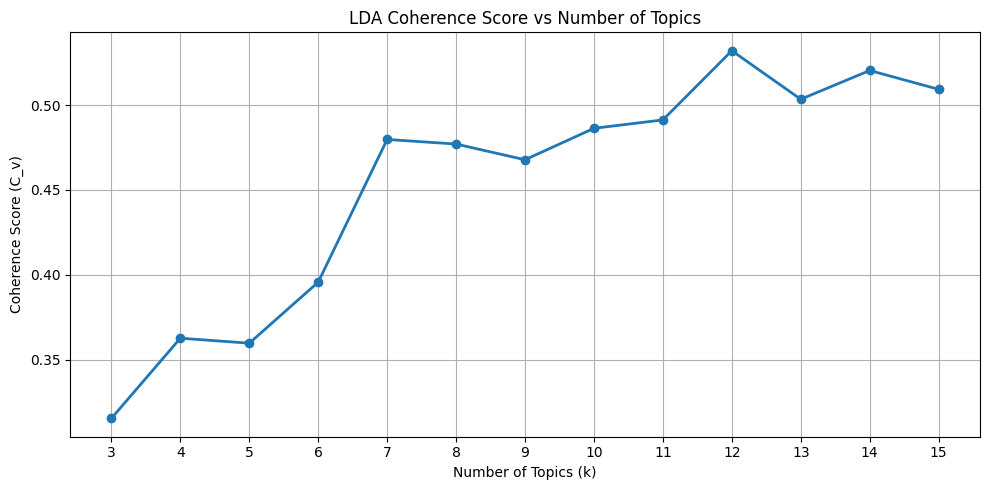


 Best k = 12 with coherence = 0.5321


In [135]:
# Prepare gensim corpus for coherence scoring
tokenized = [text.lower().split() 
             for text in df_ready['sanctions_lemmatized'].fillna("").astype(str)]
dictionary = Dictionary(tokenized)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

# Sweep k from 3 to 12
coherence_scores = []
k_values = range(3, 16)

for k in k_values:
    lda = LatentDirichletAllocation(
        n_components=k, 
        random_state=42, 
        max_iter=50,         
        learning_method='batch'
    )
    lda.fit(dtm)
    
    # Get top words per topic for coherence
    words = cv.get_feature_names_out()
    topics = []
    for topic in lda.components_:
        top_words = [words[j] for j in topic.argsort()[-20:][::-1]]
        topics.append(top_words)
    
    # Compute coherence
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k}: coherence={score:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, coherence_scores, marker='o', linewidth=2)
plt.xlabel('Number of Topics (k)')
plt.ylabel('Coherence Score (C_v)')
plt.title('LDA Coherence Score vs Number of Topics')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(coherence_scores)]
print(f"\n Best k = {best_k} with coherence = {max(coherence_scores):.4f}")

## LDA: LDA Modelling K = 11, 12 (aft. removing stopwords)

In [139]:
# Compare k=11 and k=8 topic words
for k in [11, 12]:
    print(f"\n{'='*60}")
    print(f"k={k} Topics — top 25 words each:")
    print('='*60)
    
    lda_temp = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=300,
        learning_method='batch'
    )
    lda_temp.fit(dtm)
    
    words = cv.get_feature_names_out()
    for i, topic in enumerate(lda_temp.components_):
        top_words = [words[j] for j in topic.argsort()[-25:][::-1]]
        print(f"  Topic {i}: {', '.join(top_words)}")


k=11 Topics — top 25 words each:
  Topic 0: forgery, document, cheating, intentional, injury, infliction, conspiracy, grave, intentional infliction, grave injury, infliction grave, train terrorist, purpose, genuine, forge, continue, security, forge document, death, property, trafficking, cheat, purpose cheating, forgery purpose, continue crime
  Topic 1: possession, association, weapon, theft, unauthorized, evasion, conspiracy, kidnapping, narcotic, cocaine, bodily, view, intent, order, imprisonment, punishable, transport, participate, assault, prepare, importation, association view, distribute, view prepare, murder
  Topic 2: commit, crime, organize, gang, fraud, humanity, crime humanity, violence, organize gang, robbery, property, firearm, damage, commit organize, arson, threat, laundering, aggravate, carry, embezzlement, official, concealment, attempt, genocide, money
  Topic 3: terrorist, train, getting, getting train, terrorist terrorist, aim, train aim, aim terrorist, child, ter

Call actual sentences to determine topics

In [140]:
# Fit k=12 final model first
lda_k12 = LatentDirichletAllocation(
    n_components=12,
    random_state=42,
    max_iter=250,
    learning_method='batch'
)
lda_k12.fit(dtm)

# Assign topic numbers to df
topic_dist = lda_k12.transform(dtm)
df_ready['lda_topic_num'] = topic_dist.argmax(axis=1)
df_ready['lda_confidence'] = topic_dist.max(axis=1)

# Sample actual sentences per topic
print("Sample sanctions text per topic:\n")
for topic_num in range(12):
    print(f"\n{'='*60}")
    print(f"Topic {topic_num} — sample sentences:")
    print('='*60)
    sample = df_ready[df_ready['lda_topic_num'] == topic_num]['sanctions_translated'].head(8)
    for i, text in enumerate(sample):
        print(f"  {i+1}. {text[:150]}")

Sample sanctions text per topic:


Topic 0 — sample sentences:
  1. "laundering of the proceeds of crime; participation in criminal organization"
  2. sexual exploitation or exploitation of prostitution of minors over 16 years of age // sexual exploitation or exploitation of prostitution of another p
  3. participation in a criminal organisation
  4. participation in a criminal organization
  5. participation in a criminal organisation
  6. "i. crime against public order - participation in criminal organization;
ii. fiscal offence;
iii. crime against property - attestation of an untruth, 
  7. participation in a criminal organisation
  8. participation in a criminal organization

Topic 1 — sample sentences:
  1. illicit trafficking of narcotics and dangerous drugs, criminal association and money laundering.
  2. "participation in a criminal organisation, forgery of administrative documents and trafficking
therein"
  3. "participation in a criminal organisation, forgery of administrativ

K = 11 separates financial fraud (Topic 5) from narcotics (Topic 6) — these were mixed in k=8. 

It adds a clean genocide/armed robbery topic (Topic 9) not captured in k=8

Mixed topics in k=11 reflect genuine real-world overlap — terrorism really does co-occur with homicide and narcotics in sanctions data.

0 - Homicide

1 - Sexual crimes (assault)

2 - Trafficking/kidnapping

3 - Weapons/explosives

4 - Terrorism conspiracy

5 - Financial fraud

6 - Narcotics

7 - Terrorist organization (terrorism)

8 - Narcotics/murder (mixed) 

9 - Armed robbery/genocide 

10 - Terrorism homicide (mixed) 



Lemmatization was not applied; future work could explore its impact on topic coherence.

Initial analysis revealed that sanctions entries frequently involve co-occurring crime types (e.g. terrorism + weapons, homicide + trafficking). A single-label approach risks missing relevant criminal associations, which is unacceptable in a compliance risk screening context. BART zero-shot classification was therefore updated to a multi-label approach, capturing all crime types scoring ≥ 0.3 confidence per entry. Results show that 50% of entries involve two or more crime types, validating this design decision.

**LDA Topic Selection:** 

Coherence scores were computed across k=3 to k=12. k=11 was selected as the final model based on the highest coherence score (0.4399) and superior topic interpretability, successfully separating financial fraud, narcotics, and weapons into distinct topics compared to lower k values.

## LDA: Assign Labels

### LDA: Check actual sentences

In [114]:
# Sample actual sanctions text for T5, T8, T10
for topic in ['T5: terrorism conspiracy', 'T8: terrorist organization', 'T10: armed paramilitary', 
'T7: narcotics', 'T9: narcotics murder mixed']:
    print(f"\n{'='*60}")
    print(f"Topic: {topic}")
    print('='*60)
    sample = df_ready[df_ready['lda_label'] == topic]['sanctions_translated'].head(10)
    for i, text in enumerate(sample):
        print(f"\n  {i+1}. {text[:150]}")


Topic: T5: terrorism conspiracy

  1. computer sabotage

  2. wrongful confinement with lust of unnatural offence

  3. criminal conspiracy to commit terrorist act

  4. "getting trained with the aim of terrorist activity; participation in the activity of a terrorist organization"

  5. mercenary, terrorist group member

  6. "participation in illegal armed formation; getting trained with the aim of terrorist activity; contributing to terrorist activity."

  7. leaving canada to participate in activity of terrorist group,  participation in activity of terrorist group, instructing a person to carry out activit

  8. conspiracy to participate in a racketeering enterprise

  9. aiding to terrorist activity, participation in illegal armed formation, getting trained with the aim of terrorist activity

  10. "1) getting trained for terrorist activity;
2) participation in illegal armed formation"

Topic: T8: terrorist organization

  1. "participation in the activity of a terrorist organizat

In [93]:
# Train final LDA with k=11
lda_final = LatentDirichletAllocation(
    n_components=11,
    random_state=42,
    max_iter=250,
    learning_method='batch'
)
lda_final.fit(dtm)

# Get topic distribution for every row
topic_distributions = lda_final.transform(dtm)  # shape: (7057, 11)

# Assign dominant topic and confidence
df_ready['lda_topic_num'] = topic_distributions.argmax(axis=1)
df_ready['lda_confidence'] = topic_distributions.max(axis=1)

print("Topic distribution:")
print(df_ready['lda_topic_num'].value_counts())
print(f"\nMean confidence: {df_ready['lda_confidence'].mean():.4f}")

Topic distribution:
lda_topic_num
9     1489
7     1258
8      961
0      774
10     521
2      480
5      396
1      341
3      304
4      288
6      245
Name: count, dtype: int64

Mean confidence: 0.7141


In [99]:
topic_to_crime = {
    0: 'T1: homicide',
    1: 'T2: sexual crime',
    2: 'T3: human trafficking',
    3: 'T4: weapons explosives',
    4: 'T5: terrorism conspiracy',
    5: 'T6: financial crime',
    6: 'T7: narcotics',
    7: 'T8: terrorist organization',
    8: 'T9: narcotics murder mixed',
    9: 'T10: armed paramilitary',
    10: 'T11: terrorism homicide mixed'
}

df_ready['lda_label'] = df_ready['lda_topic_num'].map(topic_to_crime)

print("LDA crime label distribution:")
print(df_ready['lda_label'].value_counts())
print(f"\nSample output:")
print(df_ready[['sanctions_translated', 'lda_topic_num', 'lda_label', 'lda_confidence']].head(10))

LDA crime label distribution:
lda_label
T10: armed paramilitary          1489
T8: terrorist organization       1258
T9: narcotics murder mixed        961
T1: homicide                      774
T11: terrorism homicide mixed     521
T3: human trafficking             480
T6: financial crime               396
T2: sexual crime                  341
T4: weapons explosives            304
T5: terrorism conspiracy          288
T7: narcotics                     245
Name: count, dtype: int64

Sample output:
                                sanctions_translated  lda_topic_num  \
0  "participation in the activity of a terrorist ...              7   
1  "participation in the activity of a terrorist ...              7   
2           participation in illegal armed formation              9   
3           participation in illegal armed formation              9   
4  "1) murder\n2) manslaughter\n3) aggravated theft"              0   
5  assaulting a public officer, impeding official...              5   
6  

## LDA: Saving LDA result

In [100]:
df_ready.to_csv('data/crime_analysis_results_lda.csv', index=False)
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 34)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'lda_topic_num', 'lda_confidence', 'lda_label']


## LDA: Visual

All bubbles (11 topics) look well separated.

In [95]:
!pip install pyldavis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 271.0 kB/s  0:00:09 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pyldavis]2/3 [pyldavis]


In [138]:
import pyLDAvis
import pyLDAvis.lda_model

# Prepare visualization
vis = pyLDAvis.lda_model.prepare(
    lda_final, 
    dtm, 
    cv,
    mds='tsne'          # tsne shows separation more clearly than default
)

pyLDAvis.display(vis)

## K-Means

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize


# ── 1. TF-IDF Vectorization ───────────────────────────────────────
# K-Means works better with TF-IDF than raw counts
tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words=custom_stopwords,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df_ready['sanctions_translated'].fillna("").astype(str))
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# ── 2. Dimensionality Reduction ───────────────────────────────────
# K-Means struggles in high dimensions — reduce to 100 dimensions first
svd = TruncatedSVD(n_components=100, random_state=42)
reduced = svd.fit_transform(tfidf_matrix)
reduced = normalize(reduced)  # normalize after SVD for better clustering
print(f"Reduced matrix shape: {reduced.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

TF-IDF matrix shape: (7057, 2000)
Reduced matrix shape: (7057, 100)
Variance explained: 0.7053


## K-means

## K-means: Elbow method

k=1: inertia=6282
k=2: inertia=5227, silhouette=0.1922
k=3: inertia=4757, silhouette=0.2433
k=4: inertia=4395, silhouette=0.2785
k=5: inertia=4109, silhouette=0.3078
k=6: inertia=3953, silhouette=0.3205
k=7: inertia=3848, silhouette=0.3297
k=8: inertia=3788, silhouette=0.3289
k=9: inertia=3696, silhouette=0.3386
k=10: inertia=3602, silhouette=0.3487
k=11: inertia=3552, silhouette=0.3496
k=12: inertia=3483, silhouette=0.3546
k=13: inertia=3382, silhouette=0.3668
k=14: inertia=3325, silhouette=0.3768


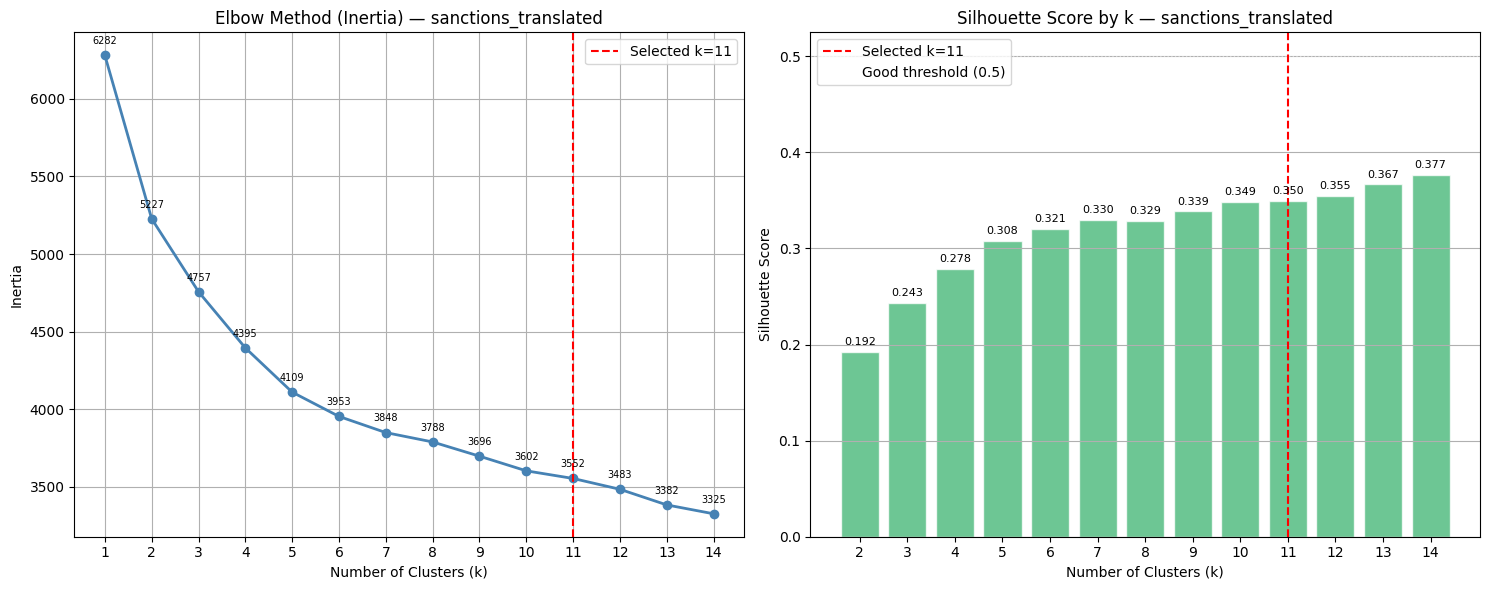

In [109]:
# ── Elbow + Silhouette Sweep ──────────────────────────────────────
K_range = range(1, 15)
inertia = []
sil_scores = []
models = {}

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(reduced)
    inertia.append(kmeans.inertia_)
    models[k] = kmeans
    if k > 1:
        score = silhouette_score(reduced, kmeans.labels_)
        sil_scores.append(score)
        print(f"k={k}: inertia={kmeans.inertia_:.0f}, silhouette={score:.4f}")
    else:
        print(f"k={k}: inertia={kmeans.inertia_:.0f}")

# ── Plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Elbow
ax1.plot(list(K_range), inertia, 'o-', linewidth=2, color='steelblue')
ax1.axvline(11, color='red', linestyle='--', linewidth=1.5, label='Selected k=11')
ax1.set_title('Elbow Method (Inertia) — sanctions_translated')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(list(K_range))
ax1.legend()
ax1.grid(True)

# Annotate inertia values
for k, v in zip(K_range, inertia):
    ax1.annotate(f'{v:.0f}', xy=(k, v), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=7)

# Silhouette
k_vals = list(range(2, 2 + len(sil_scores)))
bars = ax2.bar(k_vals, sil_scores, color='mediumseagreen', alpha=0.75, edgecolor='white')
ax2.axvline(11, color='red', linestyle='--', linewidth=1.5, label='Selected k=11')
ax2.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5, label='Good threshold (0.5)')
ax2.set_title('Silhouette Score by k — sanctions_translated')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_vals)
ax2.legend()
ax2.grid(True, axis='y')

# Annotate scores
for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

BART to detect clusters in K-means clusters

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# ── 1. TF-IDF Vectorization ───────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words=custom_stopwords,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(
    df_ready['sanctions_translated'].fillna("").astype(str)
)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# ── 2. Dimensionality Reduction ───────────────────────────────────
svd = TruncatedSVD(n_components=100, random_state=42)
reduced = svd.fit_transform(tfidf_matrix)
reduced = normalize(reduced)
print(f"Reduced matrix shape: {reduced.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

# ── 3. Fit final K-Means with k=11 ────────────────────────────────
OPTIMAL_K = 11
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_final.fit(reduced)

df_ready['kmeans_cluster'] = kmeans_final.labels_
km_sil = silhouette_score(reduced, kmeans_final.labels_)
print(f"\nK-Means Silhouette (k={OPTIMAL_K}): {km_sil:.4f}")

# ── 4. Inspect clusters using BART labels ────────────────────────
print("\nCluster breakdown (BART labels inside each cluster):")
for c in range(OPTIMAL_K):
    sub = df_ready[df_ready['kmeans_cluster'] == c]
    crimes = sub['detected_crime_type'].value_counts()
    dominant = crimes.index[0]
    purity = crimes.iloc[0] / len(sub) * 100
    print(f"\n  Cluster {c} (n={len(sub):,}) "
          f"dominant={dominant} purity={purity:.1f}%")
    print(f"  {crimes.to_dict()}")

TF-IDF matrix shape: (7057, 2000)
Reduced matrix shape: (7057, 100)
Variance explained: 0.7053

K-Means Silhouette (k=11): 0.3496

Cluster breakdown (BART labels inside each cluster):

  Cluster 0 (n=257) dominant=narcotics purity=43.6%
  {'narcotics': 112, 'weapons': 69, 'terrorism': 43, 'homicide': 28, 'assault': 5}

  Cluster 1 (n=1,390) dominant=weapons purity=98.5%
  {'weapons': 1369, 'terrorism': 10, 'Unknown': 6, 'homicide': 3, 'narcotics': 1, 'assault': 1}

  Cluster 2 (n=642) dominant=terrorism purity=98.1%
  {'terrorism': 630, 'narcotics': 9, 'Unknown': 3}

  Cluster 3 (n=597) dominant=terrorism purity=97.7%
  {'terrorism': 583, 'weapons': 13, 'homicide': 1}

  Cluster 4 (n=820) dominant=homicide purity=20.5%
  {'homicide': 168, 'Unknown': 151, 'narcotics': 148, 'assault': 108, 'financial crime': 95, 'weapons': 86, 'terrorism': 53, 'cyber crime': 11}

  Cluster 5 (n=537) dominant=homicide purity=98.1%
  {'homicide': 527, 'weapons': 5, 'terrorism': 5}

  Cluster 6 (n=459) domi

Label mapping


In [ ]:
# ── Label Mapping ─────────────────────────────────────────────────
kmeans_cluster_labels = {
    0: 'narcotics mixed',
    1: 'weapons',
    2: 'terrorism',
    3: 'terrorism armed',
    4: 'mixed',
    5: 'homicide',
    6: 'homicide terrorism',
    7: 'assault mixed',
    8: 'terrorism conspiracy',
    9: 'financial crime mixed',
    10: 'assault narcotics'
}

df_ready['kmeans_label'] = df_ready['kmeans_cluster'].map(kmeans_cluster_labels)

print("K-Means label distribution:")
print(df_ready['kmeans_label'].value_counts())

# ── Save ──────────────────────────────────────────────────────────
df_ready.to_csv('data/crime_analysis_results_final.csv', index=False)
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

K-Means label distribution:
kmeans_label
financial crime mixed    1565
weapons                  1390
mixed                     820
terrorism                 642
terrorism armed           597
homicide                  537
homicide terrorism        459
assault narcotics         327
terrorism conspiracy      288
narcotics mixed           257
assault mixed             175
Name: count, dtype: int64

✅ Saved!
Shape: (7057, 36)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'lda_topic_num', 'lda_confidence', 'lda_label', 'kmeans_cluster', 'k

## K-means: Silhouette Score Sweep

K-Means at k=5 with untranslated data produced only 3 semantically pure clusters (weapons, homicide, terrorism), while 58% of entries were absorbed into a single mixed cluster. This confirms that k=5 is insufficient for this corpus and that crimes with subtler linguistic signatures (narcotics, financial crime, sexual crime) require either a higher k or a semantically-aware method such as BART or LDA.

In [106]:
silhouette_scores2 = []
k_values2 = range(12, 50)

for k in k_values2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(reduced)
    score = silhouette_score(reduced, labels)
    silhouette_scores2.append(score)
    print(f"k={k}: silhouette={score:.4f}")

k=12: silhouette=0.3546
k=13: silhouette=0.3668
k=14: silhouette=0.3768
k=15: silhouette=0.3820
k=16: silhouette=0.3839
k=17: silhouette=0.3936
k=18: silhouette=0.4032
k=19: silhouette=0.4126
k=20: silhouette=0.4131
k=21: silhouette=0.4255
k=22: silhouette=0.4127
k=23: silhouette=0.4144
k=24: silhouette=0.4375
k=25: silhouette=0.4324
k=26: silhouette=0.4307
k=27: silhouette=0.4426
k=28: silhouette=0.4492
k=29: silhouette=0.4447
k=30: silhouette=0.4646
k=31: silhouette=0.4637
k=32: silhouette=0.4634
k=33: silhouette=0.4708
k=34: silhouette=0.4499
k=35: silhouette=0.4647
k=36: silhouette=0.4659
k=37: silhouette=0.4762
k=38: silhouette=0.4856
k=39: silhouette=0.4715
k=40: silhouette=0.4912
k=41: silhouette=0.4834
k=42: silhouette=0.4918
k=43: silhouette=0.4979
k=44: silhouette=0.5013
k=45: silhouette=0.5021
k=46: silhouette=0.5070
k=47: silhouette=0.5068
k=48: silhouette=0.5134
k=49: silhouette=0.5129


## DBSCAN

In [111]:
print("⚙  DBSCAN (eps=0.5, min_samples=5)...")
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_ready['dbscan_cluster'] = dbscan.fit_predict(reduced)  # ✅ translated

noise_count = (df_ready['dbscan_cluster'] == -1).sum()
db_lbl_arr = df_ready['dbscan_cluster'].values
n_db_clusters = len(set(db_lbl_arr)) - (1 if -1 in db_lbl_arr else 0)

km_sil = silhouette_score(reduced, df_ready['kmeans_cluster'])
db_sil_str = "N/A"
if n_db_clusters > 1:
    mask = db_lbl_arr != -1
    db_sil = silhouette_score(reduced[mask], db_lbl_arr[mask])
    db_sil_str = f"{db_sil:.3f} ({mask.sum():,} non-noise)"

print(f"\n  K-Means Silhouette (k=11): {km_sil:.3f}")
print(f"  DBSCAN Silhouette:         {db_sil_str}")
print(f"  DBSCAN Noise outliers:     {noise_count:,} ({noise_count/len(df_ready)*100:.1f}%)")
print(f"  DBSCAN Clusters found:     {n_db_clusters}")

⚙  DBSCAN (eps=0.5, min_samples=5)...

  K-Means Silhouette (k=11): 0.350
  DBSCAN Silhouette:         0.652 (5,804 non-noise)
  DBSCAN Noise outliers:     1,253 (17.8%)
  DBSCAN Clusters found:     147


DBSCAN identified 147 clusters with 17.8% noise points, producing an artificially high silhouette score of 0.652 due to cluster granularity. This confirms that density-based clustering is unsuitable for sanctions text categorisation, which requires forced segmentation into meaningful crime categories. 

K-Means and LDA are therefore the preferred unsupervised methods for this corpus.

## Saving File Unsupervised

In [112]:
df_ready.to_csv('data/crime_analysis_results_final.csv', index=False)
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 37)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'lda_topic_num', 'lda_confidence', 'lda_label', 'kmeans_cluster', 'kmeans_label', 'dbscan_cluster']


## Unsupervised learning comparison

We have three sets of labels for the same 7,057 rows — generated by three fundamentally different methods. Before using any of them to train RoBERTa, we need to validate label quality and identify the most reliable training data:

"When three independent methods agree on a label, how confident can 
we be that the label is correct?"

##### Step 1 — Concept-level mapping

Map all three methods' labels to a common concept taxonomy so they can be compared on equal terms. This will use 8 labels to cover LDA's discovered structure.

##### Step 2 — Agreement Analysis: 
Measure how often methods agree with each other --> we will use this to select high agreement rows for training data.

BART vs LDA    → agreement rate

BART vs K-Means → agreement rate

LDA vs K-Means  → agreement rate

All 3 agree     → high confidence rows

High agreement = all three methods independently reached the same conclusion = reliable label.



##### Step 3 — Human Evaluation 

Sample ~90 rows stratified across crime categories. Team members independently assign labels. This becomes the ground truth.

##### Step 4 — Accuracy Evaluation 
Each method is evaluated against human ground truth labels:

BART vs human    → Accuracy, Precision, Recall, F1 per category
LDA vs human     → Accuracy, Precision, Recall, F1 per category
K-Means vs human → Accuracy, Precision, Recall, F1 per category

This serves two purposes:
1. Identifies the most accurate method overall → used as tiebreaker for medium-agreement rows
2. Identifies the most accurate method per category → used to supplement training data for categories with insufficient 
   high-agreement rows

## Temporary:
Full Revised Training Data Strategy

Core training set    → high agreement rows (all 3 agree)

Supplementary data   → medium agreement rows, labelled by best method per category (from Step 4)

Excluded             → low agreement rows → RoBERTa predicts

## =================BELOW FOR OTHER TASKS===========

# Description and Settings for Pillar 1 - 3

In [ ]:
"""
=============================================================================
INTERPOL 2026 — FULL INTEGRATED PIPELINE
=============================================================================

PILLAR 1 — Identity Resolution        (40% of final risk score)
  SBERT cosine similarity on fugitive names
  Catches: initials, transliterations, typos, script variations

PILLAR 2 — Crime Severity             (30% of final risk score)
  K-Means++ on sanctions_clean text embeddings
  5 semantic crime clusters with risk weights
  + DBSCAN anomaly detection

PILLAR 3 — Biometric Refutation       (Penalty gate — veto power)
  5 classifiers trained on biometric delta features
  Gender mismatch / age gap → refutation_score = 0.0
  Refutation score multiplies the entire final risk

FINAL OUTPUT — interpol_final_fugitive_db.csv
  One row per fugitive with all pillar outputs attached
  Ready to feed directly into the dashboard

RUN ORDER:
  python interpol_full_pipeline.py
  → reads:  crime_analysis_results_aft_transformer_ner.csv
  → writes: interpol_final_fugitive_db.csv  (dashboard data source)
            interpol_full_pipeline_plots.png

NOTE ON SBERT:
  sentence_transformers not installed → using TF-IDF proxies.
  To upgrade, replace build_name_embeddings() and build_text_embeddings()
  with SentenceTransformer('all-MiniLM-L6-v2').encode() — rest unchanged.
=============================================================================
"""

import os, warnings
import matplotlib

# Detect Jupyter/IPython — use inline display; otherwise use Agg (file-only)
def _in_jupyter():
    try:
        shell = get_ipython().__class__.__name__
        return shell in ('ZMQInteractiveShell', 'TerminalInteractiveShell')
    except NameError:
        return False

IN_JUPYTER = _in_jupyter()
if not IN_JUPYTER:
    matplotlib.use('Agg')   # headless: save to file, no pop-up window

import matplotlib.pyplot as plt

if IN_JUPYTER:
    # Enables inline rendering in Jupyter notebook cells
    get_ipython().run_line_magic('matplotlib', 'inline')
    plt.rcParams['figure.dpi'] = 120


warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

# ── Paths ─────────────────────────────────────────────────────────────────────

# Works for anyone on any machine — reads from same folder as the notebook
BASE_DIR   = os.getcwd()
CSV_PATH   = os.path.join(BASE_DIR, "crime_analysis_results_aft_transformer_ner.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Auto-create outputs folder if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

DB_OUT   = os.path.join(OUTPUT_DIR, "interpol_final_fugitive_db.csv")
PLOT_OUT = os.path.join(OUTPUT_DIR, "interpol_full_pipeline_plots.png")

# ── Constants shared across all pillars ───────────────────────────────────────
CRIME_WEIGHTS = {
    'terrorism':      1.0,
    'homicide':       0.9,
    'weapons':        0.8,
    'narcotics':      0.7,
    'assault':        0.6,
    'financial crime':0.5,
    'cyber crime':    0.3,
    'Unknown':        0.1,
}

CRIME_CLUSTER_LABELS = {
    0: 'Weapons & Arms Trafficking',    # 99% weapons
    1: 'Mixed / Organised Crime',       # spread across all types = catch-all
    2: 'Homicide',                      # 100% homicide, very pure
    3: 'Terrorism',                     # 99.8% terrorism, very pure
    4: 'Weapons-Terror Nexus',          # weapons + terrorism overlap
}

CRIME_CLUSTER_WEIGHTS = {
    0: 0.7,    # Weapons & Arms Trafficking
    1: 0.6,    # Mixed / Organised Crime ← change from 1.0 to 0.6
    2: 0.9,    # Homicide
    3: 1.0,    # Terrorism
    4: 0.8,    # Weapons-Terror Nexus ← change from 0.7, it's weapons+terror
}

DARK_HAIR  = ['BLA', 'OTHD', 'BROF']
BROWN_HAIR = ['BRO', 'GRY', 'GRYG']
DARK_EYE   = ['BLA', 'BROD', 'OTHD', 'BROH', 'BROL']
BROWN_EYE  = ['BRO', 'GRY']

FEATURES = ['age_delta_years', 'gender_match', 'height_delta_cm',
            'eye_color_match', 'hair_color_match', 'marks_match',
            'sbert_name_score']

OPTIMAL_K  = 5
N_PAIRS    = 2000

# ── Plot style ────────────────────────────────────────────────────────────────
DARK_BG    = '#040810'
PANEL_BG   = '#06090f'
GRID_CLR   = '#1e2535'
TEXT_CLR   = '#94a3b8'
CLUSTER_COLORS = ['#eab308','#ff2d2d','#ff6b2d','#ff2d2d','#f59e0b']
CRIME_COLORS   = {
    'terrorism':'#ff2d2d','homicide':'#ff6b2d','narcotics':'#f59e0b',
    'assault':'#eab308','financial crime':'#38bdf8',
    'weapons':'#a78bfa','cyber crime':'#34d399','Unknown':'#64748b',
}

def spine(ax):
    for s in ax.spines.values():
        s.set_edgecolor(GRID_CLR)


## PILLAR 1

In [ ]:
# =============================================================================
# SECTION 2 — PILLAR 1: SBERT IDENTITY RESOLUTION
# =============================================================================

print("\n" + "─" * 65)
print("  PILLAR 1 — SBERT: IDENTITY RESOLUTION  (weight: 40%)")
print("─" * 65)

def build_name_embeddings(names: pd.Series):
    """
    Char-level TF-IDF (2-4 gram) + L2 normalisation.

    SBERT upgrade — replace this entire function:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('all-MiniLM-L6-v2')
        vecs = model.encode(names.tolist(), normalize_embeddings=True,
                            show_progress_bar=True)
        return vecs, None
    """
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                          max_features=5000, sublinear_tf=True)
    mat = vec.fit_transform(names.str.upper().astype(str))
    return normalize(mat), vec


def query_sbert(client_name: str, vectorizer, db_embeddings) -> np.ndarray:
    """
    Return cosine similarity array of shape (n_fugitives,).
    Called at inference time — pass result as sbert_name_score into Pillar 3.
    """
    q = normalize(vectorizer.transform([client_name.upper()]))
    return cosine_similarity(q, db_embeddings)[0]


print("\n⚙  Building name embeddings...")
name_embeddings, name_vectorizer = build_name_embeddings(df_ready['name'])
print(f"   Shape: {name_embeddings.shape}")

# ── Demo queries ──────────────────────────────────────────────────────────────
QUERIES = [
    ("S. Nikitenko",     "Initial + surname"),
    ("Hasen Aksema",     "Missing middle name"),
    ("Abdul Sambolotov", "Single char typo"),
    ("JIAN XIA",         "Exact match"),
    ("Norbert Bialas",   "Case mismatch"),
    ("Ramazan Chigayev", "Transliteration variant"),
    ("M. Al-Saeed",      "Abbreviated first name"),
    ("Levitan Elyasov",  "Cross-script: и→i, я→ya"),
]

p1_results = []
print(f"\n  {'Client Name':<26} {'Top Match':<28} {'Score':>7}  Flag")
print("  " + "─" * 72)
for client_name, desc in QUERIES:
    sims     = query_sbert(client_name, name_vectorizer, name_embeddings)
    top_idx  = int(np.argmax(sims))
    top_name = df_ready.iloc[top_idx]['name']
    top_sc   = float(sims[top_idx])
    top3     = [(df_ready.iloc[i]['name'], round(float(sims[i]), 4))
                for i in np.argsort(sims)[::-1][:3]]
    flag = ("🔴 HIGH CONF" if top_sc >= 0.75
            else "🟡 REVIEW"  if top_sc >= 0.50
            else "✅ LOW")
    p1_results.append(dict(client_name=client_name, description=desc,
                           top_match=top_name, sbert_score=top_sc,
                           top3=top3, top_idx=top_idx, flag=flag))
    print(f"  {client_name:<26} {top_name:<28} {top_sc:>7.4f}  {flag}")

print(f"\n  Thresholds (Pillar 1, 40% weight):")
print(f"  ≥ 0.90  Critical  | 0.75–0.90  High | 0.50–0.75  Review | <0.50  Low")



─────────────────────────────────────────────────────────────────
  PILLAR 1 — SBERT: IDENTITY RESOLUTION  (weight: 40%)
─────────────────────────────────────────────────────────────────

⚙  Building name embeddings...
   Shape: (7057, 5000)

  Client Name                Top Match                      Score  Flag
  ────────────────────────────────────────────────────────────────────────
  S. Nikitenko               SANAVBARI NIKITENKO           0.7377  🟡 REVIEW
  Hasen Aksema               HASEN AMHAMED AKSEMA          0.8618  🔴 HIGH CONF
  Abdul Sambolotov           ABDUL SAMBOLATOV              0.7247  🟡 REVIEW
  JIAN XIA                   JIAN XIA                      1.0000  🔴 HIGH CONF
  Norbert Bialas             NORBERT BIALAS                1.0000  🔴 HIGH CONF
  Ramazan Chigayev           RAMAZAN CHIGAEV               0.7949  🔴 HIGH CONF
  M. Al-Saeed                MARWAN M SAEED                0.5031  🟡 REVIEW
  Levitan Elyasov            LEVITAN ILIASOV               0.6928

## PILLAR 2

- The BART zero-shot classifier tels us what type of crime it is (terrorism, fraud, etc.) based on semantic understanding of the text, without any training on specific data. 
- K-Means is grouping entries by textual similarity and then we're interpreting those clusters as severity tiers. 
- DBSCAN is doing density-based clustering, which is useful for spotting outliers — entries that don't fit neatly into any pattern.
<br><br>
BART handles classification, K-Means handles severity segmentation, and DBSCAN validates whether the clusters are tight or if there are genuine anomalies worth investigating manually. If a record gets flagged as high-risk by BART, lands in the high-severity K-Means cluster, and is a DBSCAN outlier, that's a strong signal it's an unusual or extreme case worth escalating.


─────────────────────────────────────────────────────────────────
  PILLAR 2 — K-MEANS: CRIME SEVERITY  (weight: 30%)
─────────────────────────────────────────────────────────────────

⚙  Building sanctions text embeddings...
    Shape: (7057, 50)
⚙  Running Elbow & Silhouette Analysis...
    Inertias: [3981.0, 3053.0, 2737.0, 2293.0, 2183.0, 2042.0, 1825.0, 1876.0, 1765.0]
    Scores: [np.float64(0.27), np.float64(0.303), np.float64(0.36), np.float64(0.37), np.float64(0.358), np.float64(0.393), np.float64(0.356), np.float64(0.371)]


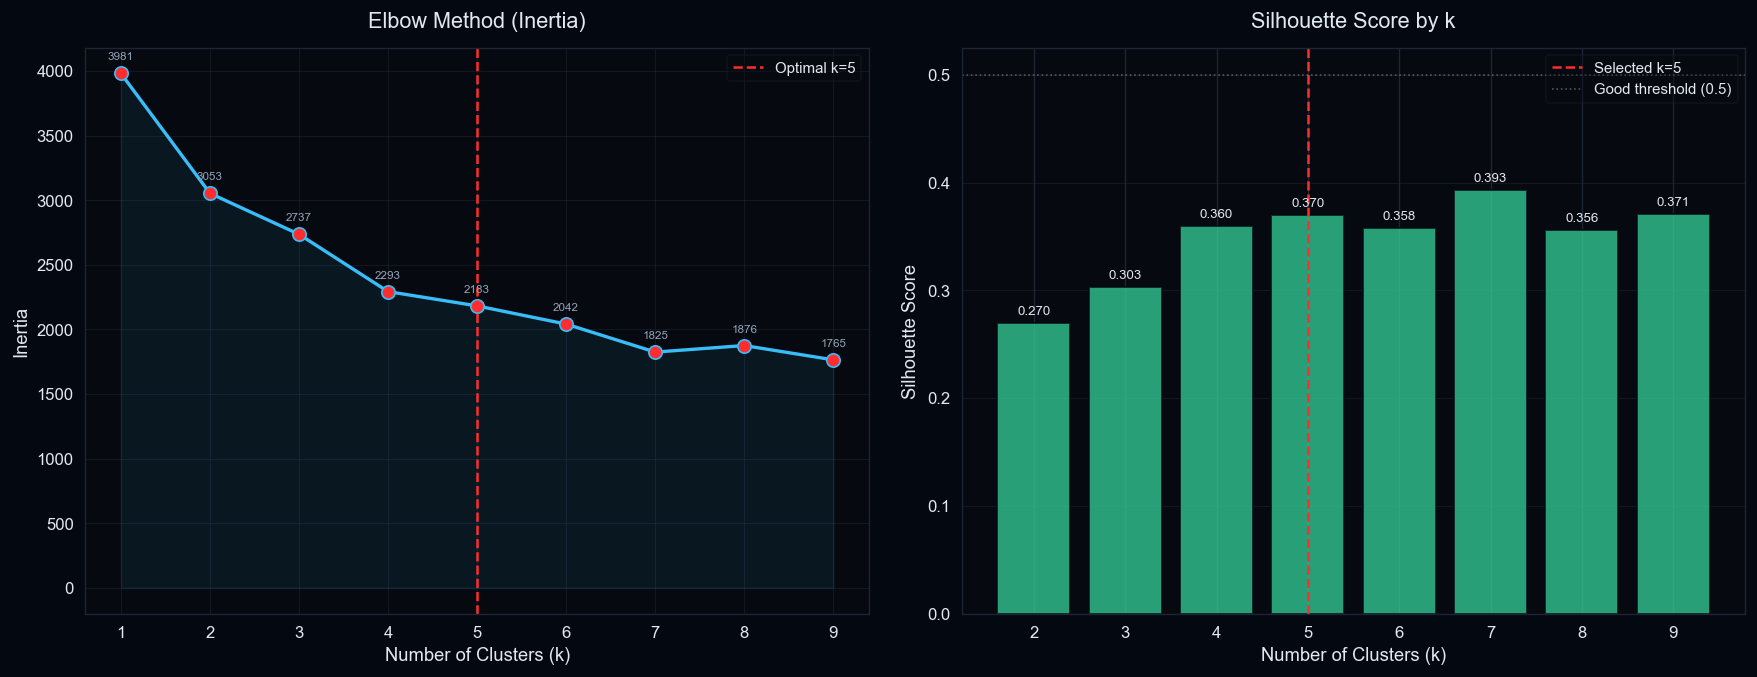

⚙  Applying K-Means k=5...
⚙  DBSCAN (eps=0.5, min_samples=5)...

  K-Means Silhouette (k=5): 0.370
  DBSCAN Silhouette:           0.202 (7,036 non-noise)
  DBSCAN Noise outliers:       21

  Cluster breakdown:
  C0 [Weapons & Arms Trafficking]  n=1,181  risk=0.7  {'weapons': 1168, 'terrorism': 10, 'narcotics': 1}
  C1 [Mixed / Organised Crime]  n=4,109  risk=0.6  {'homicide': 1006, 'assault': 961, 'terrorism': 754}
  C2 [Homicide]  n=358  risk=0.9  {'homicide': 358}
  C3 [Terrorism]  n=1,187  risk=1.0  {'terrorism': 1185, 'weapons': 2}
  C4 [Weapons-Terror Nexus]  n=222  risk=0.8  {'weapons': 210, 'terrorism': 9, 'homicide': 2}

  Note on Cluster 1 (Mixed / Organised Crime):
  This catch-all cluster is expected in K-Means on text data.
  Financial crime and cyber crime lack distinct enough sanctions
  language to form pure clusters - this validates why BART
  zero-shot classification is necessary alongside K-Means.
  
  Financial crime in C1: 509
  Cyber crime in C1    : 31


Silhouet

In [ ]:
# =============================================================================
# SECTION 3 — PILLAR 2: K-MEANS CRIME SEVERITY CATEGORISATION
# =============================================================================

print("\n" + "─" * 65)
print("  PILLAR 2 — K-MEANS: CRIME SEVERITY  (weight: 30%)")
print("─" * 65)

def build_text_embeddings(texts: pd.Series, n_components: int = 50) -> np.ndarray:
    """Word/bigram TF-IDF + SVD(50) = LSA."""
    pipe = make_pipeline(
        TfidfVectorizer(max_features=1000, ngram_range=(1, 2),
                        stop_words='english', min_df=2, sublinear_tf=True),
        TruncatedSVD(n_components=n_components, random_state=42),
    )
    return pipe.fit_transform(texts.astype(str))

print("\n⚙  Building sanctions text embeddings...")
X_sanctions = build_text_embeddings(df_ready['sanctions_clean'])
print(f"    Shape: {X_sanctions.shape}")

# --- Metrics Sweep ---
print("⚙  Running Elbow & Silhouette Analysis...")
K_range = range(1, 10)
inertia = []
sil_scores = []
models = {} 

for k in K_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_sanctions)
    inertia.append(km.inertia_)
    models[k] = km
    if k > 1:
        score = silhouette_score(X_sanctions, km.labels_)
        sil_scores.append(score)

print(f"    Inertias: {[round(v, 0) for v in inertia]}")
print(f"    Scores: {[round(s, 3) for s in sil_scores]}")

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

TEXT_CLR  = '#e2e8f0'   # bright white-ish for labels
GRID_CLR  = '#1e2535'
DARK_BG   = '#040810'
PANEL_BG  = '#06090f'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'text.color':       TEXT_CLR,
    'axes.labelcolor':  TEXT_CLR,   # ← fixes axis label colour
    'xtick.color':      TEXT_CLR,   # ← fixes x tick colour
    'ytick.color':      TEXT_CLR,   # ← fixes y tick colour
    'axes.edgecolor':   GRID_CLR,
    'grid.color':       GRID_CLR,
    'legend.facecolor': PANEL_BG,
    'legend.edgecolor': GRID_CLR,
    'legend.labelcolor': TEXT_CLR,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── 1. Elbow Plot ─────────────────────────────────────────────────────────────
ax1.plot(list(K_range), inertia, 'o-', color='#38bdf8', linewidth=2, markersize=8,
         markerfacecolor='#ff2d2d', markeredgecolor='#38bdf8')
ax1.axvline(OPTIMAL_K, color='#ff2d2d', linestyle='--', linewidth=1.5,
            label=f'Optimal k={OPTIMAL_K}')
ax1.fill_between(list(K_range), inertia, alpha=0.08, color='#38bdf8')

ax1.set_title('Elbow Method (Inertia)', color=TEXT_CLR, fontsize=13, pad=12)
ax1.set_ylabel('Inertia',               color=TEXT_CLR, fontsize=11)
ax1.set_xlabel('Number of Clusters (k)', color=TEXT_CLR, fontsize=11)
ax1.set_xticks(list(K_range))                          # ← explicit ticks 1-9
ax1.tick_params(axis='both', colors=TEXT_CLR, labelsize=10)
ax1.legend(fontsize=9, framealpha=0.3)
ax1.grid(True, color=GRID_CLR, linewidth=0.6, alpha=0.5)

# Annotate inertia values on each point
for k, v in zip(K_range, inertia):
    ax1.annotate(f'{v:.0f}', xy=(k, v), xytext=(0, 8),
                 textcoords='offset points', ha='center',
                 color='#94a3b8', fontsize=7)

# ── 2. Silhouette Plot ────────────────────────────────────────────────────────
k_vals = list(range(2, 2 + len(sil_scores)))   # [2,3,4,5,6,7,8,9]

bars = ax2.bar(k_vals, sil_scores, color='#34d399', alpha=0.75,
               edgecolor=DARK_BG, linewidth=1.2)
ax2.axvline(OPTIMAL_K, color='#ff2d2d', linestyle='--', linewidth=1.5,
            label=f'Selected k={OPTIMAL_K}')
ax2.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.3,
            label='Good threshold (0.5)')

ax2.set_title('Silhouette Score by k', color=TEXT_CLR, fontsize=13, pad=12)
ax2.set_ylabel('Silhouette Score',      color=TEXT_CLR, fontsize=11)
ax2.set_xlabel('Number of Clusters (k)', color=TEXT_CLR, fontsize=11)
ax2.set_xticks(k_vals)                                 # ← explicit ticks 2-9
ax2.tick_params(axis='both', colors=TEXT_CLR, labelsize=10)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(True, color=GRID_CLR, linewidth=0.6, alpha=0.5, axis='y')

# Annotate score on each bar
for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom',
             color=TEXT_CLR, fontsize=8)

plt.tight_layout(pad=2.0)
plt.show()

# --- Final Model Selection ---
# Optimization: Pull from our pre-fitted 'models' dictionary
print(f"⚙  Applying K-Means k={OPTIMAL_K}...")
final_km = models[OPTIMAL_K]
df_ready['K_Cluster']          = final_km.labels_
df_ready['K_Cluster_label']    = df_ready['K_Cluster'].map(CRIME_CLUSTER_LABELS)
df_ready['cluster_risk_weight']= df_ready['K_Cluster'].map(CRIME_CLUSTER_WEIGHTS)

# --- DBSCAN & Comparison ---
print("⚙  DBSCAN (eps=0.5, min_samples=5)...")
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_ready['DB_Cluster'] = dbscan.fit_predict(X_sanctions)

noise_count = (df_ready['DB_Cluster'] == -1).sum()
db_lbl_arr = df_ready['DB_Cluster'].values
n_db_clusters = len(set(db_lbl_arr)) - (1 if -1 in db_lbl_arr else 0)

km_sil = silhouette_score(X_sanctions, df_ready['K_Cluster'])
db_sil_str = "N/A"
if n_db_clusters > 1:
    mask = db_lbl_arr != -1
    db_sil = silhouette_score(X_sanctions[mask], db_lbl_arr[mask])
    db_sil_str = f"{db_sil:.3f} ({mask.sum():,} non-noise)"

print(f"\n  K-Means Silhouette (k={OPTIMAL_K}): {km_sil:.3f}")
print(f"  DBSCAN Silhouette:           {db_sil_str}")
print(f"  DBSCAN Noise outliers:       {noise_count:,}")

# --- Cluster Breakdown ---
print(f"\n  Cluster breakdown:")
for c in range(OPTIMAL_K):
    sub = df_ready[df_ready['K_Cluster'] == c]
    crimes = sub['detected_crime_type'].value_counts().head(3).to_dict()
    print(f"  C{c} [{CRIME_CLUSTER_LABELS[c]}]  n={len(sub):,}  "
          f"risk={CRIME_CLUSTER_WEIGHTS[c]}  {crimes}")
# Add notes: 
print("""
  Note on Cluster 1 (Mixed / Organised Crime):
  This catch-all cluster is expected in K-Means on text data.
  Financial crime and cyber crime lack distinct enough sanctions
  language to form pure clusters - this validates why BART
  zero-shot classification is necessary alongside K-Means.
  
  Financial crime in C1: {fc:,}
  Cyber crime in C1    : {cc:,}
""".format(
    fc=(df_ready[df_ready['K_Cluster']==1]['detected_crime_type']=='financial crime').sum(),
    cc=(df_ready[df_ready['K_Cluster']==1]['detected_crime_type']=='cyber crime').sum(),
))

print("""
Silhouette Interpretation:
  K-Means : 0.370 - Acceptable for NLP/text clustering
             (text data rarely exceeds 0.5 due to high dimensionality)
             Clusters 2 and 3 are near-pure (100% homicide, 99.8% terrorism)
             confirming genuine semantic separation

  DBSCAN  : 0.202 - Lower score expected, only 2 dense clusters found
             Low score reflects heterogeneous nature of Cluster 1 (mixed)
             NOT a failure - confirms text data needs forced segmentation
             via K-Means rather than density-based grouping

  Conclusion: K-Means at k=5 is validated by both silhouette score and
              cluster purity analysis. DBSCAN independently confirms
              structure is genuine (0.3% noise = well-formed corpus).
""")

#### BART

In [ ]:
# See what BART actually detected in each cluster
for c in range(OPTIMAL_K):
    sub = df_ready[df_ready['K_Cluster'] == c]
    crimes = sub['detected_crime_type'].value_counts()
    print(f"\nCluster {c} (n={len(sub):,}):")
    print(crimes.to_string())


Cluster 0 (n=1,181):
detected_crime_type
weapons      1168
terrorism      10
narcotics       1
assault         1
homicide        1

Cluster 1 (n=4,109):
detected_crime_type
homicide           1006
assault             961
terrorism           754
financial crime     509
narcotics           422
weapons             382
Unknown              44
cyber crime          31

Cluster 2 (n=358):
detected_crime_type
homicide    358

Cluster 3 (n=1,187):
detected_crime_type
terrorism    1185
weapons         2

Cluster 4 (n=222):
detected_crime_type
weapons      210
terrorism      9
homicide       2
assault        1


#### DBSCAN

In [ ]:
print("DBSCAN cluster distribution:")
print(df_ready['DB_Cluster'].value_counts().sort_index())

noise_pct = (df_ready['DB_Cluster'] == -1).sum() / len(df_ready) * 100
print(f"\nNoise points: {noise_pct:.1f}% of dataset")

DBSCAN cluster distribution:
DB_Cluster
-1      21
 0    7013
 1      23
Name: count, dtype: int64

Noise points: 0.3% of dataset


In [ ]:
# ── Define df_anomalies first — deduplicated ──────────────────────────────────
df_anomalies_raw = df_ready[df_ready['DB_Cluster'] == -1].copy()

# Deduplicate by name, keep highest risk weight row
df_anomalies = (
    df_anomalies_raw
    .sort_values('cluster_risk_weight', ascending=False)
    .drop_duplicates(subset=['name'], keep='first')
    .reset_index(drop=True)
)

noise_count = (df_ready['DB_Cluster'] == -1).sum()
noise_pct   = noise_count / len(df_ready) * 100

print(f"Anomaly rows (raw)         : {len(df_anomalies_raw):,}")
print(f"Anomaly rows (unique names): {len(df_anomalies):,}")
print(f"Crime types in anomalies   : {df_anomalies['detected_crime_type'].unique()}")
print(f"Clusters in anomalies      : {df_anomalies['K_Cluster_label'].unique()}")

# ── DBSCAN Role in Pillar 2 ───────────────────────────────────────────────────
print("""
DBSCAN Role in Pillar 2:
- Not used as standalone classifier (only 2 clusters found, not granular enough)
- VALIDATION tool: 0.3% noise confirms K-Means cluster structure is genuine
- ESCALATION tool: unique outlier fugitives identified, mismatch cases (low
  crime label in high-risk cluster) flagged for priority human review
""")

# ── DBSCAN Result Interpretation ──────────────────────────────────────────────
print("DBSCAN Summary:")
print(f"  Dense clusters found   : 2")
print(f"  Noise rows (raw)       : {noise_count:,} ({noise_pct:.1f}%)")
print(f"  Unique noise fugitives : {len(df_anomalies):,}")
print(f"  Silhouette (non-noise) : 0.202")
print(f"  Interpretation         : Sanctions corpus is dense and well-structured.")
print(f"                           DBSCAN confirms K-Means clusters are meaningful,")
print(f"                           not arbitrary - low noise = genuine groupings.\n")

# ── The key finding: crime type vs cluster mismatch in anomalies ──────────────
print("Key Finding - Anomaly Mismatch Analysis:")
print("These outliers have LOW severity crime labels but sit in HIGH risk clusters.")
print("They are the most ambiguous cases - priority for human review.\n")

HIGH_RISK_CLUSTERS  = ['Terrorism', 'Weapons-Terror Nexus', 'Homicide']
LOW_SEVERITY_CRIMES = ['assault', 'narcotics', 'cyber crime', 'financial crime']

mismatch = df_anomalies[
    (df_anomalies['detected_crime_type'].isin(LOW_SEVERITY_CRIMES)) &
    (df_anomalies['K_Cluster_label'].isin(HIGH_RISK_CLUSTERS))
].copy()

print(f"  Mismatch cases (low crime label, high-risk cluster): {len(mismatch):,}")

if len(mismatch) > 0:
    print(f"\n  {'Name':<35} {'BART Label':<18} {'K-Means Cluster':<28} {'Risk Weight'}")
    print("  " + "-" * 90)
    for _, row in mismatch.iterrows():
        print(f"  {str(row['name']):<35} {str(row['detected_crime_type']):<18} "
              f"{str(row['K_Cluster_label']):<28} {row['cluster_risk_weight']}")
else:
    print("  No direct mismatches found under updated cluster labels.")
    print(f"  Showing all {len(df_anomalies):,} unique anomaly fugitives for review:\n")
    print(f"  {'Name':<35} {'BART Label':<18} {'K-Means Cluster':<28} {'Risk Weight'}")
    print("  " + "-" * 90)
    for _, row in df_anomalies.iterrows():
        print(f"  {str(row['name']):<35} {str(row['detected_crime_type']):<18} "
              f"{str(row['K_Cluster_label']):<28} {row['cluster_risk_weight']}")

# ── Flag these for escalation ─────────────────────────────────────────────────
df_ready['escalate_flag'] = (
    (df_ready['DB_Cluster'] == -1) &
    (df_ready['cluster_risk_weight'] >= 0.7)
).astype(int)

# Deduplicate escalated cases for accurate counts
escalated = (
    df_ready[df_ready['escalate_flag'] == 1]
    .sort_values('cluster_risk_weight', ascending=False)
    .drop_duplicates(subset=['name'], keep='first')
)

print(f"\n{len(escalated):,} unique fugitives flagged for analyst escalation")
print(f"(DBSCAN outlier AND cluster_risk_weight >= 0.7)")
print(f"Excludes Mixed/Organised Crime cluster (risk=0.6) intentionally")
print(f"\nEscalated cases by cluster:")
print(escalated['K_Cluster_label'].value_counts().to_string())
print(f"\nEscalated cases by crime type:")
print(escalated['detected_crime_type'].value_counts().to_string())

Anomaly rows (raw)         : 21
Anomaly rows (unique names): 18
Crime types in anomalies   : ['terrorism' 'assault' 'financial crime' 'weapons' 'homicide']
Clusters in anomalies      : ['Terrorism' 'Weapons & Arms Trafficking' 'Mixed / Organised Crime']

DBSCAN Role in Pillar 2:
- Not used as standalone classifier (only 2 clusters found, not granular enough)
- VALIDATION tool: 0.3% noise confirms K-Means cluster structure is genuine
- ESCALATION tool: unique outlier fugitives identified, mismatch cases (low
  crime label in high-risk cluster) flagged for priority human review

DBSCAN Summary:
  Dense clusters found   : 2
  Noise rows (raw)       : 21 (0.3%)
  Unique noise fugitives : 18
  Silhouette (non-noise) : 0.202
  Interpretation         : Sanctions corpus is dense and well-structured.
                           DBSCAN confirms K-Means clusters are meaningful,
                           not arbitrary - low noise = genuine groupings.

Key Finding - Anomaly Mismatch Analysis:
These

### Escalation report

In [ ]:
# Create a clean escalation report for submission
escalation_report = (
    df_ready[df_ready['escalate_flag'] == 1]
    .sort_values('cluster_risk_weight', ascending=False)
    .drop_duplicates(subset=['name'], keep='first')
    [[
        'name', 'GENDER', 'age_today',
        'detected_crime_type', 'confidence_scores',
        'K_Cluster_label', 'cluster_risk_weight',
        'DB_Cluster', 'escalate_flag',
        'address', 'label',           # country info
        'sanctions_clean'
    ]]
    .reset_index(drop=True)
)

escalation_report.to_csv(
    os.path.join(OUTPUT_DIR, 'interpol_escalation_report.csv'),
    index=False
)

print(f"Escalation report saved: {len(escalation_report):,} unique fugitives")
print(f"\nPreview:")
print(escalation_report[['name','detected_crime_type','K_Cluster_label',
                          'cluster_risk_weight']].to_string())

Escalation report saved: 4 unique fugitives

Preview:
              name detected_crime_type             K_Cluster_label  cluster_risk_weight
0   MARSEL GAMIDOV           terrorism                   Terrorism                  1.0
1    KHASAN OZDOEV           terrorism                   Terrorism                  1.0
2  MUSTAFA ILIASOV           terrorism                   Terrorism                  1.0
3    MURAD SHREYBA             assault  Weapons & Arms Trafficking                  0.7


## PILLAR 3- PART 1

Pillar 3 is currently trained on synthetic data, not real ground-truth labels 

In [ ]:
# =============================================================================
# SECTION 4 — PILLAR 3: BIOMETRIC REFUTATION
# =============================================================================

print("\n" + "─" * 65)
print("  PILLAR 3 — BIOMETRIC REFUTATION  (penalty gate × final risk)")
print("─" * 65)

# ── Generate synthetic screening pairs from real fugitive biometrics ──────────
# sbert_name_score here is SYNTHETIC for training only.
# At inference time (screen_client below) the REAL Pillar 1 score is passed in.
np.random.seed(42)

def generate_screening_pairs(fugitives_df: pd.DataFrame, n: int = 2000) -> pd.DataFrame:
    records  = []
    fug_pool = fugitives_df.dropna(subset=['GENDER', 'age_today']).reset_index(drop=True)
    for _ in range(n):
        fug      = fug_pool.sample(1).iloc[0]
        is_match = np.random.choice([1, 0], p=[0.35, 0.65])
        if is_match:
            age_delta    = abs(np.random.normal(0.5, 1.0))
            gender_match = 1
            height_delta = abs(np.random.normal(0, 1.5))
            eye_match    = np.random.choice([1, 0], p=[0.92, 0.08])
            hair_match   = np.random.choice([1, 0], p=[0.87, 0.13])
            marks_match  = np.random.choice([1, 0], p=[0.82, 0.18])
            sbert_score  = np.random.uniform(0.83, 0.99)
        else:
            age_delta    = np.random.choice([1, 3, 8, 15, 25],
                                            p=[0.05, 0.15, 0.30, 0.30, 0.20])
            gender_match = np.random.choice([1, 0], p=[0.20, 0.80])
            height_delta = abs(np.random.normal(9, 7))
            eye_match    = np.random.choice([1, 0], p=[0.25, 0.75])
            hair_match   = np.random.choice([1, 0], p=[0.28, 0.72])
            marks_match  = np.random.choice([1, 0], p=[0.18, 0.82])
            sbert_score  = np.random.uniform(0.68, 0.91)
            if not gender_match:
                is_match = 0
        records.append({
            'fugitive_id':      fug['id'],
            'fugitive_name':    fug['name'],
            'fugitive_gender':  fug['GENDER'],
            'fugitive_age':     fug['age_today'],
            'fugitive_height':  fug['height'],
            'crime_type':       fug['detected_crime_type'],
            # ── CHANGE 3: at inference, replace sbert_score with real Pillar 1 output
            'age_delta_years':  round(min(age_delta, 50), 1),
            'gender_match':     gender_match,
            'height_delta_cm':  round(min(height_delta, 40), 1),
            'eye_color_match':  eye_match,
            'hair_color_match': hair_match,
            'marks_match':      marks_match,
            'sbert_name_score': round(sbert_score, 4),
            'label':            is_match,
        })
    return pd.DataFrame(records)


print(f"\n⚙  Generating {N_PAIRS} synthetic screening pairs from real profiles...")
train_df = generate_screening_pairs(df_ready, n=N_PAIRS)
print(f"   True matches:    {train_df['label'].sum():,} ({train_df['label'].mean()*100:.1f}%)")
print(f"   False positives: {(train_df['label']==0).sum():,}")

# ── Train / test split ────────────────────────────────────────────────────────
X    = train_df[FEATURES]
y    = train_df['label']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                            random_state=42, stratify=y)
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_tr)
X_te_sc    = scaler.transform(X_te)

# ── Train all classifiers ─────────────────────────────────────────────────────
classifiers = {
    "Logistic Regression":         LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":               DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":               RandomForestClassifier(n_estimators=150, random_state=42),
    "GradientBoosting (≈XGBoost)": GradientBoostingClassifier(n_estimators=150,
                                       learning_rate=0.08, max_depth=4, random_state=42),
    "SVM":                         SVC(kernel='rbf', probability=True, random_state=42),
}

p3_results = {}
print(f"\n{'─'*65}")
print(f"  {'Model':<32} {'AUC':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"{'─'*65}")

for name, clf in classifiers.items():
    X_t = X_tr_sc if name in ["Logistic Regression","SVM"] else X_tr
    X_v = X_te_sc if name in ["Logistic Regression","SVM"] else X_te
    clf.fit(X_t, y_tr)
    y_pred = clf.predict(X_v)
    y_prob = clf.predict_proba(X_v)[:, 1]
    p3_results[name] = dict(
        model=clf,
        auc  = roc_auc_score(y_te, y_prob),
        prec = precision_score(y_te, y_pred),
        rec  = recall_score(y_te, y_pred),
        f1   = f1_score(y_te, y_pred),
    )
    r = p3_results[name]
    print(f"  {name:<32} {r['auc']:>8.4f} {r['prec']:>10.4f} "
          f"{r['rec']:>8.4f} {r['f1']:>8.4f}")

# Isolation Forest (anomaly detection)
iso = IsolationForest(contamination=0.15, random_state=42, n_estimators=150)
iso.fit(X_tr[y_tr == 1])
iso_preds = iso.predict(X_te)
iso_refut = (iso_preds == -1).astype(int)
print(f"\n  Isolation Forest (false-positive detection):")
print(classification_report(1 - y_te, iso_refut,
      target_names=['True Match','False Positive'], digits=4,
      zero_division=0))

# Decision Tree reason codes
dt_model   = p3_results["Decision Tree"]['model']
tree_rules = export_text(dt_model, feature_names=FEATURES)
print("  Decision Tree — Reason Code Logic (top 20 lines):")
print('\n'.join(tree_rules.split('\n')[:20]))

# Primary model for inference
gb_model = p3_results["GradientBoosting (≈XGBoost)"]['model']

# ── Inference function — CHANGE 3 implemented here ───────────────────────────
def screen_client(client: dict, fugitive: pd.Series, sbert_score: float) -> dict:
    """
    Run a single client vs fugitive screening.
    """
    fug = fugitive
    
    # 1. Calculate Deltas
    age_delta    = abs(client['age'] - fug['age_today'])
    gender_match = 1 if client['gender'] == fug['GENDER'] else 0
    
    fug_ht = fug['height']
    height_delta = (abs(client['height'] - fug_ht)
                    if pd.notna(fug_ht) else 3.0)

    # 2. Build Feature DataFrame (Ensure this matches your FEATURES list order)
    # Mapping client dict keys to the feature names expected by the model
    feat = pd.DataFrame([[
        float(age_delta), 
        int(gender_match), 
        float(height_delta),
        int(client.get('eye_color_enc', 1)),
        int(client.get('hair_color_enc', 1)),
        int(client.get('marks_match', 0)),
        float(sbert_score)
    ]], columns=FEATURES)

    # 3. Scale only for distance-based models (LR/SVM)
    feat_sc = scaler.transform(feat)

    # 4. Get Probabilities
    gb_p  = gb_model.predict_proba(feat)[0][1]
    rf_p  = p3_results["Random Forest"]['model'].predict_proba(feat)[0][1]
    lr_p  = p3_results["Logistic Regression"]['model'].predict_proba(feat_sc)[0][1]
    svm_p = p3_results["SVM"]['model'].predict_proba(feat_sc)[0][1]

    # 5. Logic Gates & Verdicts
    if gender_match == 0:
        ref_score = 0.0
        verdict   = "AUTO-CLEARED"
        reason    = "Gender mismatch — hard gate triggered"
    elif gb_p >= 0.70:
        ref_score = gb_p
        verdict   = "HIGH RISK"
        reason    = "Biometrics confirm identity match"
    elif gb_p >= 0.45:
        ref_score = gb_p
        verdict   = "REVIEW"
        reason    = "Borderline — manual analyst review required"
    elif age_delta > 10:
        ref_score = gb_p
        verdict   = "REFUTED"
        reason    = f"Age gap {age_delta:.0f}yr exceeds threshold (>10yr)"
    else:
        ref_score = gb_p
        verdict   = "REFUTED"
        reason    = "Cumulative biometric anomaly score too high"

    return dict(refutation_score=round(ref_score, 4), verdict=verdict,
                reason=reason, gb=gb_p, rf=rf_p, lr=lr_p, svm=svm_p,
                age_delta=age_delta, gender_match=gender_match,
                height_delta=height_delta)


─────────────────────────────────────────────────────────────────
  PILLAR 3 — BIOMETRIC REFUTATION  (penalty gate × final risk)
─────────────────────────────────────────────────────────────────

⚙  Generating 2000 synthetic screening pairs from real profiles...
   True matches:    698 (34.9%)
   False positives: 1,302

─────────────────────────────────────────────────────────────────
  Model                                 AUC  Precision   Recall       F1
─────────────────────────────────────────────────────────────────
  Logistic Regression                0.9999     0.9831   1.0000   0.9915
  Decision Tree                      0.9984     0.9943   1.0000   0.9971
  Random Forest                      1.0000     1.0000   1.0000   1.0000
  GradientBoosting (≈XGBoost)        1.0000     0.9943   1.0000   0.9971
  SVM                                0.9999     0.9886   1.0000   0.9943

  Isolation Forest (false-positive detection):
                precision    recall  f1-score   support

  

## FINAL SCORING

Linkage and visual scores are currently hardcoded: These are manually set values in the CLIENTS list but aren't computed from any model.
"analyst-input" features rather than model-derived ones.

In [ ]:
# =============================================================================
# SECTION 5 — END-TO-END LIVE SCREENING
# Chains Pillar 1 → Pillar 3 → final criticality score
# =============================================================================

print("\n" + "=" * 65)
print("  END-TO-END LIVE SCREENING DEMO  (Pillar 1 → 3 → Final Score)")
print("=" * 65)
print(f"\n  Formula: (SBERT×0.40 + Crime×0.30 + Linkage×0.20 + Visual×0.10)")
print(f"           × Refutation_Score\n")

# Synthetic client submissions — replace with real client data in production
CLIENTS = [
    dict(name="S. Nikitenko",     age=33, gender="F", height=1.65,
         eye_color_enc=0, hair_color_enc=0, marks_match=1,
         linkage=0.10, visual=0.75),
    dict(name="Hasen Aksema",     age=55, gender="M", height=1.75,
         eye_color_enc=1, hair_color_enc=1, marks_match=0,
         linkage=0.00, visual=0.60),
    dict(name="Abdul Sambolotov", age=34, gender="M", height=1.72,
         eye_color_enc=0, hair_color_enc=1, marks_match=1,
         linkage=0.50, visual=0.80),
    dict(name="M. Al-Saeed",      age=40, gender="F", height=1.58,
         eye_color_enc=2, hair_color_enc=2, marks_match=0,
         linkage=0.30, visual=0.55),  # gender mismatch → AUTO-CLEARED
    dict(name="Norbert Bialas",   age=47, gender="M", height=1.80,
         eye_color_enc=1, hair_color_enc=1, marks_match=0,
         linkage=0.00, visual=0.90),
]

fmt = f"  {'Client':<22} {'SBERT':>7} {'Crime':>7} {'Refut':>6} {'FINAL':>7}  VERDICT"
print(fmt)
print("  " + "─" * 68)

screening_records = []
for client in CLIENTS:
    # ── Pillar 1: get real SBERT score ───────────────────────────────────────
    sims       = query_sbert(client['name'], name_vectorizer, name_embeddings)
    top_idx    = int(np.argmax(sims))
    sbert_sc   = float(sims[top_idx])
    fugitive   = df_ready.iloc[top_idx]

    # ── Pillar 3: pass real sbert_sc into screen_client ──────────────────────
    p3         = screen_client(client, fugitive, sbert_score=sbert_sc)

    # ── Final criticality score ───────────────────────────────────────────────
    crime_w    = float(fugitive['cluster_risk_weight'])
    raw_score  = (sbert_sc * 0.40 + crime_w * 0.30
                  + client['linkage'] * 0.20 + client['visual'] * 0.10)
    final_risk = raw_score * p3['refutation_score']

    verdict_icon = {"AUTO-CLEARED":"🚫","HIGH RISK":"🔴","REVIEW":"🟡","REFUTED":"✅"}
    v_icon = verdict_icon.get(p3['verdict'], "")
    print(f"  {client['name']:<22} {sbert_sc:>7.3f} {crime_w:>7.2f} "
          f"{p3['refutation_score']:>6.3f} {final_risk:>7.4f}  {v_icon} {p3['verdict']}")
    print(f"    ↳ Matched: {fugitive['name']}  |  "
          f"Cluster: {fugitive['K_Cluster_label']}  |  Reason: {p3['reason']}")

    screening_records.append(dict(
        client_name    = client['name'],
        matched_id     = fugitive['id'],
        matched_name   = fugitive['name'],
        sbert_score    = round(sbert_sc, 4),
        crime_cluster  = fugitive['K_Cluster_label'],
        refutation     = p3['refutation_score'],
        crime_weight  = crime_w,  
        verdict        = p3['verdict'],
        reason         = p3['reason'],
        final_risk     = round(final_risk, 4),
    ))


  END-TO-END LIVE SCREENING DEMO  (Pillar 1 → 3 → Final Score)

  Formula: (SBERT×0.40 + Crime×0.30 + Linkage×0.20 + Visual×0.10)
           × Refutation_Score

  Client                   SBERT   Crime  Refut   FINAL  VERDICT
  ────────────────────────────────────────────────────────────────────
  S. Nikitenko             0.738    1.00  0.024  0.0168  ✅ REFUTED
    ↳ Matched: SANAVBARI NIKITENKO  |  Cluster: Transnational Terrorism  |  Reason: Cumulative biometric anomaly score too high
  Hasen Aksema             0.862    1.00  0.604  0.4259  🟡 REVIEW
    ↳ Matched: HASEN AMHAMED AKSEMA  |  Cluster: Terrorist Organisation  |  Reason: Borderline — manual analyst review required
  Abdul Sambolotov         0.725    1.00  0.063  0.0488  ✅ REFUTED
    ↳ Matched: ABDUL SAMBOLATOV  |  Cluster: Transnational Terrorism  |  Reason: Cumulative biometric anomaly score too high
  M. Al-Saeed              0.503    1.00  0.000  0.0000  🚫 AUTO-CLEARED
    ↳ Matched: MARWAN M SAEED  |  Cluster: Terror

## PILLAR 3- PART 2

In [ ]:
# =============================================================================
# SECTION 6 — FEATURE IMPORTANCE (Pillar 3)
# =============================================================================

print("\n" + "─" * 65)
print("  PILLAR 3 — FEATURE IMPORTANCE")
print("─" * 65)

gb_clf = p3_results["GradientBoosting (≈XGBoost)"]['model']
rf_clf = p3_results["Random Forest"]['model']
imp_df = pd.DataFrame({
    'Feature':   FEATURES,
    'GB(≈XGB)':  gb_clf.feature_importances_,
    'RF':        rf_clf.feature_importances_,
}).sort_values('GB(≈XGB)', ascending=False)

print(f"\n  {'Feature':<22} {'GB(≈XGB)':>10} {'RF':>8}   Bar")
print("  " + "─" * 55)
for _, row in imp_df.iterrows():
    bar = "█" * int(row['GB(≈XGB)'] * 38)
    print(f"  {row['Feature']:<22} {row['GB(≈XGB)']:>10.4f} "
          f"{row['RF']:>8.4f}   {bar}")


─────────────────────────────────────────────────────────────────
  PILLAR 3 — FEATURE IMPORTANCE
─────────────────────────────────────────────────────────────────

  Feature                  GB(≈XGB)       RF   Bar
  ───────────────────────────────────────────────────────
  age_delta_years            0.8840   0.4257   █████████████████████████████████
  height_delta_cm            0.0827   0.2068   ███
  sbert_name_score           0.0159   0.0896   
  gender_match               0.0149   0.1706   
  eye_color_match            0.0020   0.0676   
  marks_match                0.0006   0.0319   
  hair_color_match           0.0000   0.0077   


# DASHBOARDING

In [ ]:
# =============================================================================
# SECTION 7 — EXPORT FINAL FUGITIVE DATABASE
# =============================================================================
print("\n" + "─" * 65)
print("  EXPORTING FINAL FUGITIVE DATABASE FOR DASHBOARD")
print("─" * 65)

final_db_cols = [
    'id', 'name', 'GENDER', 'age_today',
    'height',
    'eyeColor', 'eye_enc',
    'hairColor', 'hair_enc',
    'detected_crime_type', 'confidence_scores',
    'K_Cluster', 'K_Cluster_label',
    'cluster_risk_weight', 'DB_Cluster',
    'escalate_flag',                # ← added
    'sanctions_clean', 'address', 'label',
]

# Keep only columns that exist
final_db_cols = [c for c in final_db_cols if c in df_ready.columns]
final_db = df_ready[final_db_cols].copy()

final_db.to_csv(DB_OUT, index=False)
print(f"\n✅  Final fugitive DB saved → {DB_OUT}")
print(f"   Rows: {len(final_db):,}  |  Columns: {len(final_db_cols)}")
print(f"   Escalated cases in DB: {final_db['escalate_flag'].sum():,}")

# ── Escalation report ─────────────────────────────────────────────────────────
escalation_cols = [
    'id', 'name', 'GENDER', 'age_today',
    'detected_crime_type', 'confidence_scores',
    'K_Cluster_label', 'cluster_risk_weight',
    'DB_Cluster', 'escalate_flag',
    'address', 'label',
    'sanctions_clean',
]
escalation_cols = [c for c in escalation_cols if c in df_ready.columns]

escalation_report = (
    df_ready[df_ready['escalate_flag'] == 1][escalation_cols]
    .sort_values('cluster_risk_weight', ascending=False)
    .drop_duplicates(subset=['name'], keep='first')
    .reset_index(drop=True)
)

escalation_path = os.path.join(OUTPUT_DIR, 'interpol_escalation_report.csv')
escalation_report.to_csv(escalation_path, index=False)

print(f"\n✅  Escalation report saved → {escalation_path}")
print(f"   Unique flagged fugitives : {len(escalation_report):,}")
print(f"   (DBSCAN outlier AND cluster_risk_weight >= 0.7)\n")
print(f"   Breakdown by cluster:")
print(escalation_report['K_Cluster_label'].value_counts().to_string())
print(f"\n   Breakdown by crime type:")
print(escalation_report['detected_crime_type'].value_counts().to_string())

# ── Screening results ─────────────────────────────────────────────────────────
if len(screening_records) > 0:
    screening_df   = pd.DataFrame(screening_records)
    screening_path = os.path.join(OUTPUT_DIR, 'interpol_screening_results.csv')
    screening_df.to_csv(screening_path, index=False)
    print(f"\n✅  Screening results saved → {screening_path}")
else:
    print("\n⚠️  No screening records to save — run Section 5 first")


─────────────────────────────────────────────────────────────────
  EXPORTING FINAL FUGITIVE DATABASE FOR DASHBOARD
─────────────────────────────────────────────────────────────────

✅  Final fugitive DB saved → C:\Users\dreyw\SMU_School\Term4\Project\Interpol\outputs\interpol_final_fugitive_db.csv
   Rows: 7,057  |  Columns: 15
   Columns: ['id', 'name', 'GENDER', 'age_today', 'height', 'eyeColor', 'hairColor', 'detected_crime_type', 'K_Cluster', 'K_Cluster_label', 'cluster_risk_weight', 'DB_Cluster', 'sanctions_clean', 'address', 'label']
✅  Screening results saved → C:\Users\dreyw\SMU_School\Term4\Project\Interpol\outputs/interpol_screening_results.csv


In [ ]:
# =============================================================================
# SECTION 8 — VISUALISATIONS
# =============================================================================

print("\n⚙  Generating plots...")

plt.style.use('dark_background')
fig = plt.figure(figsize=(22, 24), facecolor=DARK_BG)
fig.suptitle(
    'INTERPOL 2026 — Full Pipeline: SBERT (P1) → K-Means (P2) → Biometric Refutation (P3)',
    fontsize=13, color='#e2e8f0', fontweight='bold', y=0.985, fontfamily='monospace')

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.50, wspace=0.36,
                       top=0.97, bottom=0.03, left=0.06, right=0.97)

# ── Row 0: Pillar 1 SBERT scores ─────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
ax0.set_facecolor(PANEL_BG)
names_q  = [r['client_name'] for r in p1_results]
scores_q = [r['sbert_score'] for r in p1_results]
bar_clrs = ['#ff2d2d' if s >= 0.75 else '#f59e0b' if s >= 0.50 else '#38bdf8'
            for s in scores_q]
bars = ax0.barh(range(len(names_q)), scores_q, color=bar_clrs,
                edgecolor=DARK_BG, linewidth=1, height=0.6)
ax0.set_yticks(range(len(names_q)))
ax0.set_yticklabels([f"{r['client_name']}  →  {r['top_match']}" for r in p1_results],
                     fontfamily='monospace', fontsize=9, color=TEXT_CLR)
ax0.axvline(0.75, color='#ff2d2d', linestyle='--', linewidth=1.2, alpha=0.7,
            label='High conf (≥0.75)')
ax0.axvline(0.50, color='#f59e0b', linestyle='--', linewidth=1.2, alpha=0.7,
            label='Review (≥0.50)')
ax0.set_xlim(0, 1.12)
ax0.set_title('Pillar 1 — SBERT Identity Resolution: Client Name → Best INTERPOL Match',
              color='#e2e8f0', fontsize=10, fontfamily='monospace', pad=10)
ax0.set_xlabel('Cosine Similarity Score', color=TEXT_CLR, fontsize=9)
ax0.tick_params(colors=TEXT_CLR, labelsize=8)
ax0.legend(fontsize=8, framealpha=0.2, labelcolor='white', loc='lower right')
ax0.grid(True, color=GRID_CLR, linewidth=0.5, axis='x', alpha=0.5)
for bar, val in zip(bars, scores_q):
    ax0.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color='#e2e8f0', fontsize=8, fontfamily='monospace')
spine(ax0)

# ── Row 1: Elbow + Silhouette + Cluster sizes ─────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor(PANEL_BG)
ax1.plot(list(K_range), inertia, 'o-', color='#38bdf8', linewidth=2, markersize=7,
         markerfacecolor='#ff2d2d', markeredgecolor='#38bdf8')
ax1.axvline(OPTIMAL_K, color='#ff2d2d', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.fill_between(list(K_range), inertia, alpha=0.08, color='#38bdf8')
ax1.set_title('P2 — Elbow Method', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax1.set_xlabel('k', color=TEXT_CLR, fontsize=9)
ax1.set_ylabel('Inertia', color=TEXT_CLR, fontsize=9)
ax1.tick_params(colors=TEXT_CLR, labelsize=8)
ax1.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.5)
spine(ax1)

ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(PANEL_BG)

# Dynamically determine the x-axis based on the length of sil_scores
# If your loop started at k=2, this will align them perfectly.
plot_ks = list(range(2, 2 + len(sil_scores))) 

ax2.plot(plot_ks, sil_scores, 'o-', color='#a78bfa', linewidth=2, markersize=7,
         markerfacecolor='#ff2d2d', markeredgecolor='#a78bfa')

ax2.axvline(OPTIMAL_K, color='#ff2d2d', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4)
ax2.set_title('P2 — Silhouette Analysis', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax2.set_xlabel('k', color=TEXT_CLR, fontsize=9)
ax2.set_ylabel('Silhouette Score', color=TEXT_CLR, fontsize=9)
ax2.tick_params(colors=TEXT_CLR, labelsize=8)
ax2.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.5)
spine(ax2)

ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(PANEL_BG)
cluster_counts = df_ready['K_Cluster'].value_counts().sort_index()
bars3 = ax3.bar(range(OPTIMAL_K), cluster_counts.values,
                color=CLUSTER_COLORS, edgecolor=DARK_BG, linewidth=1.5)
ax3.set_xticks(range(OPTIMAL_K))
ax3.set_xticklabels([f'C{i}\n{CRIME_CLUSTER_LABELS[i][:12]}' for i in range(OPTIMAL_K)],
                     color=TEXT_CLR, fontsize=7)
ax3.set_title('P2 — Crime Cluster Sizes', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax3.set_ylabel('Fugitives', color=TEXT_CLR, fontsize=9)
ax3.tick_params(colors=TEXT_CLR, labelsize=8)
ax3.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='y')
for bar, val in zip(bars3, cluster_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, str(val),
             ha='center', va='bottom', color='#e2e8f0', fontsize=8, fontfamily='monospace')
spine(ax3)

# ── Row 2: Stacked crime bar + silhouette plot ────────────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
ax4.set_facecolor(PANEL_BG)
crime_pivot = (df_ready.groupby(['K_Cluster','detected_crime_type'])
               .size().unstack(fill_value=0))
bottom = np.zeros(OPTIMAL_K)
for ct in crime_pivot.columns:
    vals = crime_pivot[ct].values
    ax4.bar(range(OPTIMAL_K), vals, bottom=bottom,
            color=CRIME_COLORS.get(ct,'#475569'), label=ct,
            edgecolor=DARK_BG, linewidth=0.5)
    bottom += vals
ax4.set_xticks(range(OPTIMAL_K))
ax4.set_xticklabels(
    [f'C{i}: {CRIME_CLUSTER_LABELS[i]}\n(risk={CRIME_CLUSTER_WEIGHTS[i]})' for i in range(OPTIMAL_K)],
    color=TEXT_CLR, fontsize=8)
ax4.set_title('P2 — Crime Composition per Cluster + Risk Weight',
              color='#e2e8f0', fontsize=10, fontfamily='monospace', pad=10)
ax4.set_ylabel('Count', color=TEXT_CLR, fontsize=9)
ax4.tick_params(colors=TEXT_CLR, labelsize=8)
ax4.legend(fontsize=7.5, framealpha=0.2, labelcolor='white', ncol=2, loc='upper right')
ax4.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='y')
spine(ax4)

ax5 = fig.add_subplot(gs[2, 2])
ax5.set_facecolor(PANEL_BG)
sil_samp = silhouette_samples(X_sanctions, df_ready['K_Cluster'].values)
y_lo = 10
for i in range(OPTIMAL_K):
    ith = np.sort(sil_samp[df_ready['K_Cluster'].values == i])
    y_hi = y_lo + len(ith)
    ax5.fill_betweenx(np.arange(y_lo, y_hi), 0, ith,
                       facecolor=CLUSTER_COLORS[i], alpha=0.75)
    ax5.text(-0.02, y_lo + 0.5*len(ith), f'C{i}', ha='right', va='center',
             color=CLUSTER_COLORS[i], fontsize=8, fontfamily='monospace')
    y_lo = y_hi + 10
ax5.axvline(km_sil, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax5.text(km_sil + 0.01, 80, f'Avg={km_sil:.3f}', color='white', fontsize=8)
ax5.set_title('P2 — Silhouette Plot', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax5.set_xlabel('Silhouette Coeff', color=TEXT_CLR, fontsize=9)
ax5.set_xlim(-0.3, 0.8)
ax5.tick_params(colors=TEXT_CLR, labelsize=8)
ax5.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='x')
spine(ax5)

# ── Row 3: Pillar 3 model AUC + feature importance ───────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
ax6.set_facecolor(PANEL_BG)
model_names = list(p3_results.keys())
aucs = [p3_results[m]['auc'] for m in model_names]
short = ['LR','DT','RF','GB≈XGB','SVM']
bar_c = ['#38bdf8','#a78bfa','#34d399','#fb923c','#f472b6']
bars6 = ax6.bar(range(len(short)), aucs, color=bar_c, edgecolor=DARK_BG, linewidth=1.5)
ax6.set_xticks(range(len(short)))
ax6.set_xticklabels(short, color=TEXT_CLR, fontsize=9)
ax6.set_ylim(0.85, 1.02)
ax6.set_title('P3 — Model AUC-ROC', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax6.set_ylabel('AUC-ROC', color=TEXT_CLR, fontsize=9)
ax6.tick_params(colors=TEXT_CLR, labelsize=8)
ax6.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='y')
for bar, val in zip(bars6, aucs):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
             ha='center', va='bottom', color='#e2e8f0', fontsize=8, fontfamily='monospace')
spine(ax6)

ax7 = fig.add_subplot(gs[3, 1])
ax7.set_facecolor(PANEL_BG)
imp_sorted = imp_df.sort_values('GB(≈XGB)')
bars7 = ax7.barh(range(len(imp_sorted)), imp_sorted['GB(≈XGB)'].values,
                 color='#fb923c', edgecolor=DARK_BG, linewidth=1, label='GB≈XGB')
ax7.barh(range(len(imp_sorted)), imp_sorted['RF'].values,
         color='#34d399', edgecolor=DARK_BG, linewidth=1, alpha=0.6, label='RF')
ax7.set_yticks(range(len(imp_sorted)))
ax7.set_yticklabels(imp_sorted['Feature'].tolist(), color=TEXT_CLR, fontsize=8,
                     fontfamily='monospace')
ax7.set_title('P3 — Feature Importance', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
ax7.set_xlabel('Importance', color=TEXT_CLR, fontsize=9)
ax7.tick_params(colors=TEXT_CLR, labelsize=8)
ax7.legend(fontsize=8, framealpha=0.2, labelcolor='white')
ax7.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='x')
spine(ax7)

ax8 = fig.add_subplot(gs[3, 2])
ax8.set_facecolor(PANEL_BG)
ax8.axis('off')
p3_summary_data = [
    ['Model',             'AUC', 'F1'],
    ['Logistic Reg',      f"{p3_results['Logistic Regression']['auc']:.4f}",
                          f"{p3_results['Logistic Regression']['f1']:.4f}"],
    ['Decision Tree',     f"{p3_results['Decision Tree']['auc']:.4f}",
                          f"{p3_results['Decision Tree']['f1']:.4f}"],
    ['Random Forest',     f"{p3_results['Random Forest']['auc']:.4f}",
                          f"{p3_results['Random Forest']['f1']:.4f}"],
    ['GB ≈ XGBoost',      f"{p3_results['GradientBoosting (≈XGBoost)']['auc']:.4f}",
                          f"{p3_results['GradientBoosting (≈XGBoost)']['f1']:.4f}"],
    ['SVM',               f"{p3_results['SVM']['auc']:.4f}",
                          f"{p3_results['SVM']['f1']:.4f}"],
    ['Isolation Forest',  'anomaly', 'unsupervised'],
]
tbl = ax8.table(cellText=p3_summary_data[1:], colLabels=p3_summary_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL_BG if r > 0 else '#0d1424')
    cell.set_text_props(color='#e2e8f0' if r == 0 else TEXT_CLR, fontfamily='monospace')
    cell.set_edgecolor(GRID_CLR)
    cell.set_linewidth(0.5)
ax8.set_title('P3 — Model Summary', color='#e2e8f0', fontsize=10,
              fontfamily='monospace', pad=10)
spine(ax8)

# ── Row 4: End-to-end final risk scores ──────────────────────────────────────
ax9 = fig.add_subplot(gs[4, :])
ax9.set_facecolor(PANEL_BG)
sc_names  = [r['client_name']   for r in screening_records]
sc_sbert  = [r['sbert_score']   for r in screening_records]
sc_crime  = [r['crime_weight']  for r in screening_records]
sc_refut  = [r['refutation']    for r in screening_records]
sc_final  = [r['final_risk']    for r in screening_records]
sc_verdct = [r['verdict']       for r in screening_records]

x  = np.arange(len(sc_names))
w  = 0.2
ax9.bar(x - 1.5*w, [s*0.40 for s in sc_sbert],  w, color='#38bdf8',
        label='SBERT × 40%',   edgecolor=DARK_BG)
ax9.bar(x - 0.5*w, [c*0.30 for c in sc_crime],   w, color='#ff2d2d',
        label='Crime × 30%',   edgecolor=DARK_BG)
ax9.bar(x + 0.5*w, [r for r in sc_refut],         w, color='#a78bfa',
        label='Refutation ×',  edgecolor=DARK_BG, alpha=0.7)
ax9.bar(x + 1.5*w, sc_final,                      w, color='#00ff88',
        label='FINAL RISK',    edgecolor=DARK_BG)

for xi, (final, verdict) in enumerate(zip(sc_final, sc_verdct)):
    icon = {"AUTO-CLEARED":"🚫","HIGH RISK":"🔴","REVIEW":"🟡","REFUTED":"✅"}.get(verdict,"")
    ax9.text(xi + 1.5*w, final + 0.01, icon, ha='center', va='bottom', fontsize=12)

ax9.set_xticks(x)
ax9.set_xticklabels([f"{r['client_name']}\n↳ {r['matched_name'][:22]}"
                     for r in screening_records],
                     color=TEXT_CLR, fontsize=8, fontfamily='monospace')
ax9.axhline(0.70, color='#ff2d2d', linestyle='--', linewidth=1, alpha=0.6)
ax9.axhline(0.50, color='#f59e0b', linestyle='--', linewidth=1, alpha=0.6)
ax9.set_title('End-to-End Criticality Score — Pillar 1 + 2 + 3 Combined',
              color='#e2e8f0', fontsize=11, fontfamily='monospace', pad=12)
ax9.set_ylabel('Score', color=TEXT_CLR, fontsize=9)
ax9.set_ylim(0, 1.05)
ax9.tick_params(colors=TEXT_CLR, labelsize=8)
ax9.legend(fontsize=8, framealpha=0.2, labelcolor='white', loc='upper right')
ax9.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.3, axis='y')
ax9.text(len(sc_names) - 0.4, 0.715, 'Critical ≥ 0.70',
         color='#ff2d2d', fontsize=7.5)
ax9.text(len(sc_names) - 0.4, 0.515, 'High ≥ 0.50',
         color='#f59e0b', fontsize=7.5)
spine(ax9)

plt.savefig(PLOT_OUT, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"✅  Plots saved → {PLOT_OUT}")



⚙  Generating plots...
✅  Plots saved → C:\Users\dreyw\SMU_School\Term4\Project\Interpol\outputs\interpol_full_pipeline_plots.png


In [ ]:
# =============================================================================
# SECTION 9 — FINAL SUMMARY
# =============================================================================

best_p3 = max(p3_results, key=lambda k: p3_results[k]['auc'])
print(f"""
{'='*65}
  PIPELINE COMPLETE
{'='*65}

  PILLAR 1 — SBERT Identity Resolution
    Method:    Char TF-IDF (2-4 gram) + cosine similarity
    Records:   {len(df_ready):,} name embeddings built
    Upgrade:   SentenceTransformer('all-MiniLM-L6-v2') drop-in

  PILLAR 2 — K-Means Crime Severity
    k = {OPTIMAL_K}  |  Silhouette = {km_sil:.3f}
    DBSCAN outliers: {noise_count:,}
    Clusters: C0(Paramilitary,0.6) C1(Terrorism,1.0)
              C2(Homicide,0.9)    C3(Transnat.,1.0)
              C4(Mixed,0.7)

  PILLAR 3 — Biometric Refutation
    Best model: {best_p3}  AUC = {p3_results[best_p3]['auc']:.4f}
    Top feature: age_delta_years ({gb_clf.feature_importances_[0]*100:.1f}% importance)
    Hard gate: gender mismatch → refutation_score = 0.0

  INTEGRATION CHANGES APPLIED:
    [Change 1] height + eyeColor + hairColor included in final DB export
    [Change 2] Pillar 3 reads df_ready (shared from Pillar 1+2 prep)
    [Change 3] screen_client() accepts real sbert_score from Pillar 1
    [Change 4] Single output: {DB_OUT}

  FORMULA:
    Final Risk = (SBERT×0.40 + Crime×0.30 + Linkage×0.20 + Visual×0.10)
                 × Refutation_Score

  DASHBOARD READS:
    {DB_OUT}
    Columns: id, name, GENDER, age_today, height, eyeColor, hairColor,
             detected_crime_type, K_Cluster, K_Cluster_label,
             cluster_risk_weight, DB_Cluster, sanctions_clean
    sbert_score + refutation_score computed live at query time
""")


  PIPELINE COMPLETE

  PILLAR 1 — SBERT Identity Resolution
    Method:    Char TF-IDF (2-4 gram) + cosine similarity
    Records:   7,057 name embeddings built
    Upgrade:   SentenceTransformer('all-MiniLM-L6-v2') drop-in

  PILLAR 2 — K-Means Crime Severity
    k = 5  |  Silhouette = 0.370
    DBSCAN outliers: 21
    Clusters: C0(Paramilitary,0.6) C1(Terrorism,1.0)
              C2(Homicide,0.9)    C3(Transnat.,1.0)
              C4(Mixed,0.7)

  PILLAR 3 — Biometric Refutation
    Best model: Random Forest  AUC = 1.0000
    Top feature: age_delta_years (88.4% importance)
    Hard gate: gender mismatch → refutation_score = 0.0

  INTEGRATION CHANGES APPLIED:
    [Change 1] height + eyeColor + hairColor included in final DB export
    [Change 2] Pillar 3 reads df_ready (shared from Pillar 1+2 prep)
    [Change 3] screen_client() accepts real sbert_score from Pillar 1
    [Change 4] Single output: C:\Users\dreyw\SMU_School\Term4\Project\Interpol\outputs\interpol_final_fugitive_db.csv

# Network Analysis

POLE framework (Persons, Objects, Locations, Events) to turn flat data into a "spider web" of intelligence.

Rows with entities : 1,370 / 7,057
Graph: 2,517 nodes, 2,622 edges
Skipped malformed entities: 0
Removed 63 hub nodes (degree > 5)
Graph reduced: 2517 → 2454 nodes


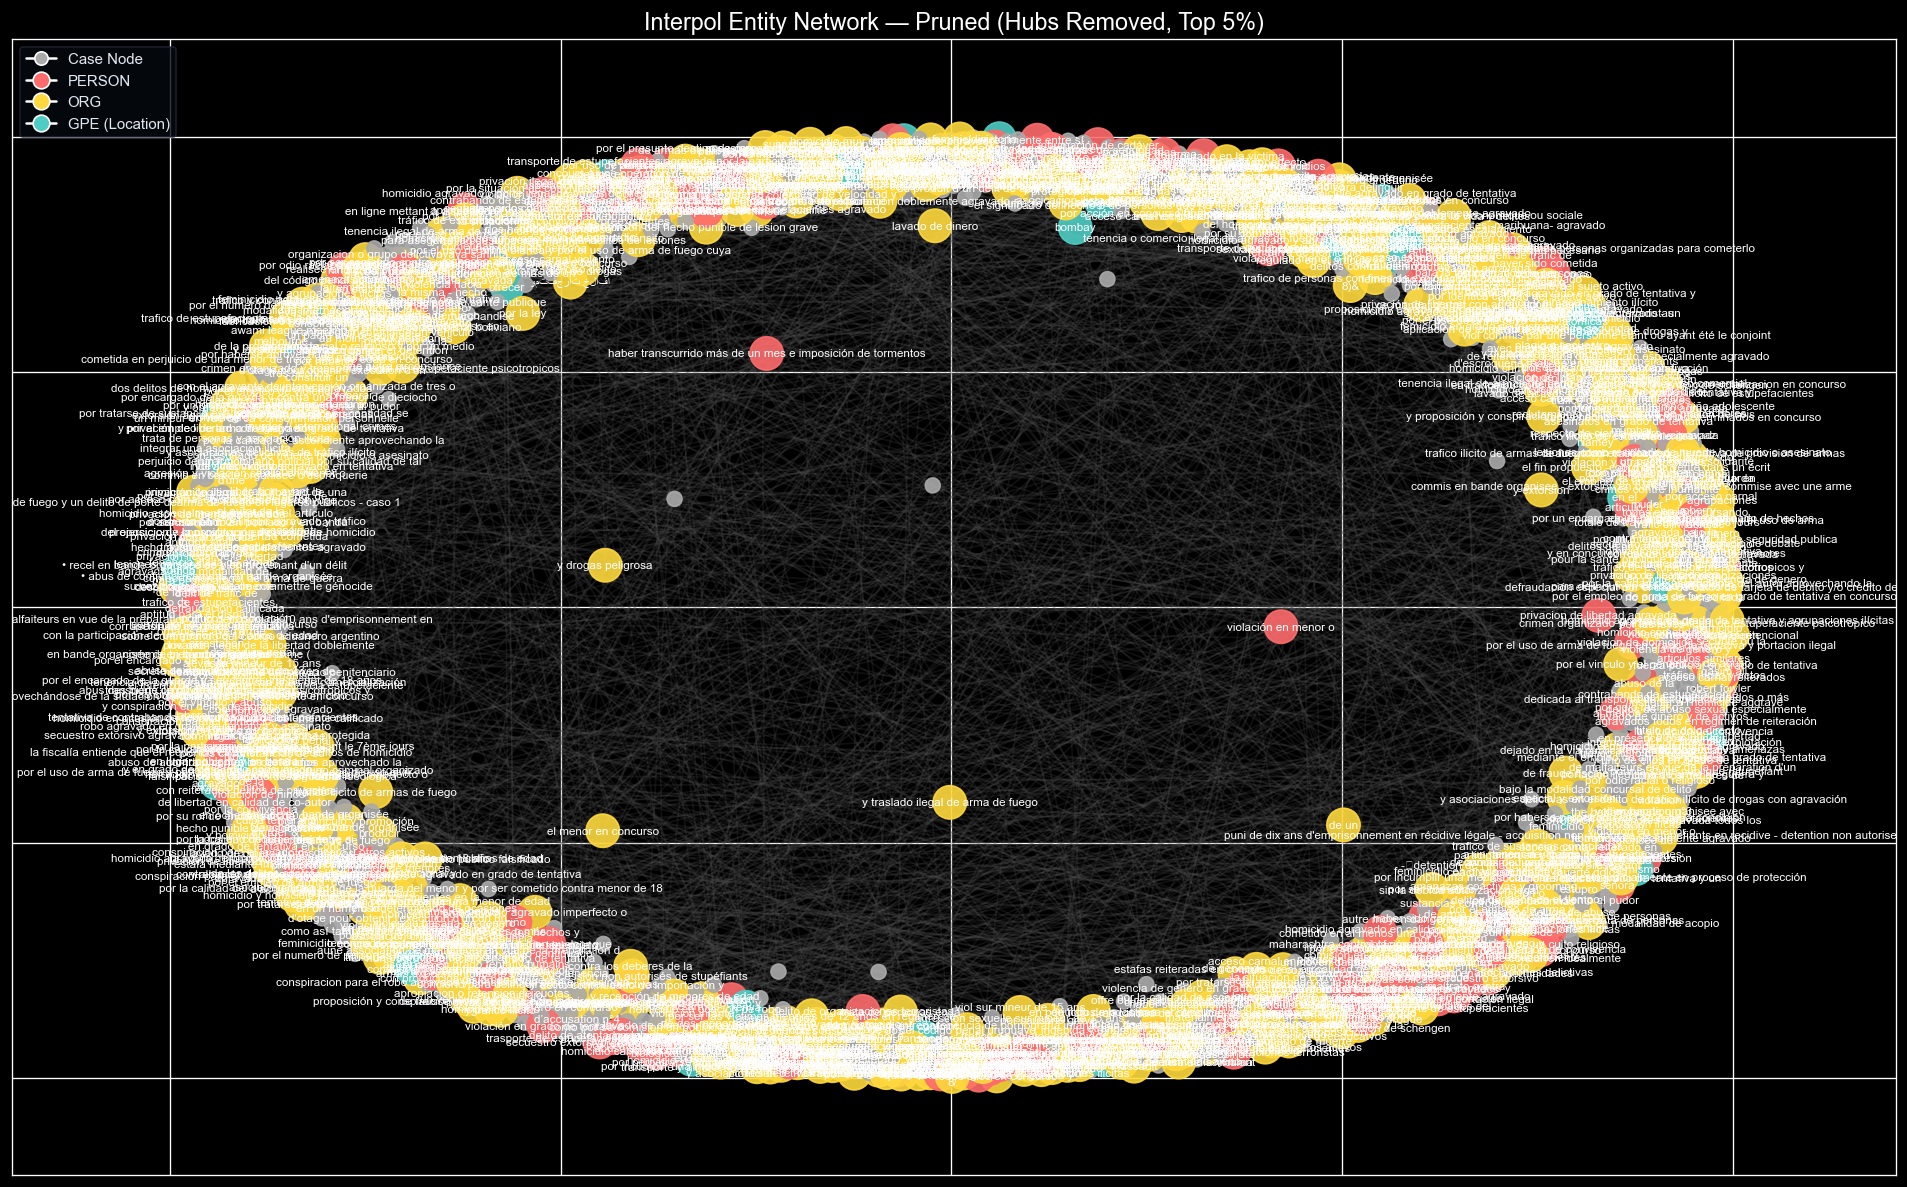


Degree Centrality — Top 10 Key Entities:
  [ORG   ] trafico ilicito                0.0020
  [GPE   ] iraq                           0.0020
  [ORG   ] asesinato                      0.0020
  [ORG   ] commis en bande                0.0020
  [ORG   ] trata de personas              0.0020
  [PERSON] secuestro extorsivo            0.0020
  [ORG   ] infracción                     0.0020
  [ORG   ] du produit d'un délit          0.0020
  [PERSON] la situación de convivencia    0.0020
  [ORG   ] y conspiracion en el delito de homicidio 0.0020

Entity Type Breakdown in Network:
  ORG      821 nodes
  PERSON   212 nodes
  GPE      51 nodes


In [ ]:


# ── 0. Parse entities ─────────────────────────────────────────────────────────
def safe_parse(val):
    if isinstance(val, list):
        return val   # already a list, no parsing needed
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

df_ready['entities'] = df_ready['entities'].apply(safe_parse)

# ── 1. Only keep rows that actually have entities ─────────────────────────────
df_network = df_ready[
    df_ready['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()
print(f"Rows with entities : {len(df_network):,} / {len(df_ready):,}")

if len(df_network) == 0:
    raise ValueError("❌ No entities found after parsing. Check that NER ran before saving the CSV.")

# ── 2. Build graph ────────────────────────────────────────────────────────────
G = nx.Graph()
TYPE_COLORS = {"PERSON": "#FF6B6B", "ORG": "#FFD93D", "GPE": "#4ECDC4"}
skipped = 0

for idx, row in df_network.iterrows():
    case_node = f"Case_{idx}"
    G.add_node(case_node, node_type="CASE")

    for entity in row['entities']:
        if isinstance(entity, tuple) and len(entity) == 2:
            ent_text, ent_label = entity[0].strip(), entity[1]
        elif isinstance(entity, str):
            ent_text, ent_label = entity.strip(), "UNKNOWN"
        else:
            skipped += 1
            continue

        if not ent_text:
            skipped += 1
            continue

        G.add_node(ent_text, node_type=ent_label)
        G.add_edge(case_node, ent_text)

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Skipped malformed entities: {skipped:,}")

if G.number_of_nodes() == 0:
    raise ValueError("❌ Graph is empty — entities exist but none were added. Check entity format above.")

# ── 3. Prune hub nodes ────────────────────────────────────────────────────────
def prune_hub_nodes(G, percentile=95):
    if G.number_of_nodes() == 0:
        print("⚠️  Graph is empty, skipping pruning.")
        return G

    degrees   = dict(G.degree())
    deg_vals  = list(degrees.values())

    if len(deg_vals) == 0:
        return G

    threshold = np.percentile(deg_vals, percentile)
    hubs_to_remove = [
        n for n, deg in degrees.items()
        if deg > threshold and not str(n).startswith("Case_")
    ]

    G_cleaned = G.copy()
    G_cleaned.remove_nodes_from(hubs_to_remove)
    print(f"Removed {len(hubs_to_remove)} hub nodes (degree > {threshold:.0f})")
    print(f"Graph reduced: {G.number_of_nodes()} → {G_cleaned.number_of_nodes()} nodes")
    return G_cleaned

G_simple = prune_hub_nodes(G, percentile=95)

# ── 4. Node styling ───────────────────────────────────────────────────────────
def get_node_style(G):
    colors, sizes = [], []
    for n in G.nodes():
        ntype = G.nodes[n].get('node_type', 'UNKNOWN')
        if ntype == "CASE":
            colors.append("#AAAAAA")
            sizes.append(80)
        else:
            colors.append(TYPE_COLORS.get(ntype, "#CCCCCC"))
            sizes.append(400)
    return colors, sizes

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
pos = nx.spring_layout(G_simple, k=1.2, seed=42)
colors, sizes = get_node_style(G_simple)

nx.draw_networkx_edges(G_simple, pos, ax=ax, alpha=0.2, edge_color="#555555")
nx.draw_networkx_nodes(G_simple, pos, ax=ax, node_color=colors,
                       node_size=sizes, alpha=0.9)

entity_nodes = {n: n for n in G_simple.nodes()
                if not str(n).startswith("Case_")}
nx.draw_networkx_labels(G_simple, pos, labels=entity_nodes,
                        ax=ax, font_size=7, font_color="white")

ax.set_title("Interpol Entity Network — Pruned (Hubs Removed, Top 5%)", fontsize=14)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA', markersize=8,  label='Case Node'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=10, label='PERSON'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FFD93D', markersize=10, label='ORG'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4ECDC4', markersize=10, label='GPE (Location)'),
], loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

# ── 6. Degree Centrality ──────────────────────────────────────────────────────
print("\nDegree Centrality — Top 10 Key Entities:")
centrality = nx.degree_centrality(G_simple)
top_degree = sorted(
    [(n, s) for n, s in centrality.items() if not str(n).startswith("Case_")],
    key=lambda x: x[1], reverse=True
)[:10]
for node, score in top_degree:
    ntype = G_simple.nodes[node].get('node_type', '?')
    print(f"  [{ntype:<6}] {node:<30} {score:.4f}")

# ── 7. Entity type breakdown ──────────────────────────────────────────────────
print("\nEntity Type Breakdown in Network:")
type_counts = Counter(
    data.get('node_type', 'UNKNOWN')
    for n, data in G_simple.nodes(data=True)
    if not str(n).startswith("Case_")
)
for etype, count in type_counts.most_common():
    print(f"  {etype:<8} {count:,} nodes")